Integrantes do grupo

# INF-0616 - Projeto 2: Redes neurais

Professora: Esther Colombini -- esther@ic.unicamp.br

Monitor: Jesus Paucar -- j236865@dac.unicamp.br

Este *notebook* faz parte da disciplina INF-0616 no curso de extensão MDC.  

Instituto de Computação - Unicamp 2026

In [6]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD

from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

from IPython.display import display

In [7]:
np.random.seed(12049)

plt.rcParams['figure.figsize'] = (12, 6)

#### Lendo o conjunto de dados

O conjunto de dados consiste em reclamações de clientes a cerca de produtos/serviços oferecidos em uma instituição bancária. ***Garanta que o arquivo*** `customer-issues.csv` ***está no mesmo diretório do notebook***.

In [8]:
import os
import pandas as pd

caminho_pasta = os.getcwd()

print("Pasta atual:", caminho_pasta)

d = pd.read_csv(os.path.join(caminho_pasta, 'customer-issues.csv'))

display(d.head())


Pasta atual: /home/julio/Documentos/MINERACAO DE DADOS/APRENDIZADO DE MAQUINA SUPERVISIONADO II/Trabalho 2


,date-received,product,sub-product,issue,sub-issue,consumer-message,state,zip-code,tags,via,resolution,timely-response?,disputed?,complaint-id
0,10/1/2016,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,AL,352XX,NaN,Web,Closed with explanation,Yes,No,2141773
1,10/17/2016,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,I purchased a new car on XXXX XXXX. The car de...,PA,177XX,Older American,Web,Closed with explanation,Yes,No,2163100
2,6/15/2015,Credit reporting,NaN,Credit reporting company's investigation,Inadequate help over the phone,An account on my credit report has a mistaken ...,VA,224XX,NaN,Web,Closed with explanation,Yes,No,1420702
3,2/3/2016,Debt collection,"Other (i.e. phone, health club, etc.)",Disclosure verification of debt,Not given enough info to verify debt,This company refuses to provide me verificatio...,TX,752XX,NaN,Web,Closed with explanation,Yes,Yes,1772196
4,2/17/2016,Debt collection,Credit card,Improper contact or sharing of info,Talked to a third party about my debt,This complaint is in regards to Square Two Fin...,NE,693XX,NaN,Web,Closed with explanation,Yes,Yes,1790634


##### Exibindo as quatro primeiras mensagens

In [9]:
print(*d.loc[:4, 'consumer-message'], sep='\n\n')

I have outdated information on my credit report that I have previously disputed that has yet to be removed this information is more then seven years old and does not meet credit reporting requirements

I purchased a new car on XXXX XXXX. The car dealer called Citizens Bank to get a 10 day payoff on my loan, good till XXXX XXXX. The dealer sent the check the next day. When I balanced my checkbook on XXXX XXXX. I noticed that Citizens bank had taken the automatic payment out of my checking account at XXXX XXXX XXXX Bank. I called Citizens and they stated that they did not close the loan until XXXX XXXX. ( stating that they did not receive the check until XXXX. XXXX. ). I told them that I did not believe that the check took that long to arrive. XXXX told me a check was issued to me for the amount overpaid, they deducted additional interest. Today ( XXXX XXXX, ) I called Citizens Bank again and talked to a supervisor named XXXX, because on XXXX XXXX. I received a letter that the loan had b

##### Extraíndo um conjunto de testes válido

As mensagens contidas neste conjunto possuem uma relação temporal.
É importante realizar a separação dos sub-conjuntos de treino/teste respeitando esta relação, de forma a garantir que o modelo não seja treinado sobre amostras no futuro e experimentado sobre o passado.

In [10]:
columna = 'date-received'

d[columna] = (
    d[columna].astype('string').str.strip().str.strip('"').str.strip("'")
)

In [11]:
d[columna] = pd.to_datetime(d[columna], format = "%m/%d/%Y", errors = 'coerce')

In [12]:
d

,date-received,product,sub-product,issue,sub-issue,consumer-message,state,zip-code,tags,via,resolution,timely-response?,disputed?,complaint-id
0,2016-10-01,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,AL,352XX,NaN,Web,Closed with explanation,Yes,No,2141773
1,2016-10-17,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,I purchased a new car on XXXX XXXX. The car de...,PA,177XX,Older American,Web,Closed with explanation,Yes,No,2163100
2,2015-06-15,Credit reporting,NaN,Credit reporting company's investigation,Inadequate help over the phone,An account on my credit report has a mistaken ...,VA,224XX,NaN,Web,Closed with explanation,Yes,No,1420702
3,2016-02-03,Debt collection,"Other (i.e. phone, health club, etc.)",Disclosure verification of debt,Not given enough info to verify debt,This company refuses to provide me verificatio...,TX,752XX,NaN,Web,Closed with explanation,Yes,Yes,1772196
4,2016-02-17,Debt collection,Credit card,Improper contact or sharing of info,Talked to a third party about my debt,This complaint is in regards to Square Two Fin...,NE,693XX,NaN,Web,Closed with explanation,Yes,Yes,1790634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199965,2016-11-09,Debt collection,Medical,False statements or representation,Attempted to collect wrong amount,Our son was taken to XXXX XXXX XXXX XXXX XXXX ...,NJ,077XX,NaN,Web,Closed with explanation,Yes,No,2201681
199966,2016-01-22,Bank account or service,Checking account,Deposits and withdrawals,NaN,"On XXXX/XXXX/13, without my authorization, Ban...",FL,347XX,NaN,Web,Closed with monetary relief,Yes,No,1753439
199967,2017-02-07,Debt collection,"Other (i.e. phone, health club, etc.)",Cont'd attempts collect debt not owed,Debt is not mine,I had an account with XXXX in XX/XX/XXXX this ...,NY,115XX,Servicemember,Web,Closed,Yes,No,2331270
199968,2017-01-04,Mortgage,Conventional fixed mortgage,"Application, originator, mortgage broker",NaN,I was contacted on XX/XX/XXXX email by XXXX fr...,FL,336XX,NaN,Web,Closed with explanation,Yes,No,2274241


In [13]:
d.sort_values(by='date-received', inplace=True)

### Modelando a classificação de tópicos baseado nas mensagens de clientes

Observando no gráfico de frequências de produto sobre as conversas que este é um problema extremamente desbalanceado. Há, entretanto, amostras suficientes para a modelagem de um estimador de tópico (de produto) levando em consideração o diálogo do cliente.

In [14]:
def frequencies(dataset, column):
    labels, counts = np.unique(dataset[column], return_counts=True)
    p = np.argsort(counts)[::-1]
    labels, counts = labels[p], counts[p]

    (sns
     .barplot(x=[l[:40] for l in labels], y=counts)
     .set_title(f'Occurrences for The {len(labels)} Classes in {column}'))
    plt.xticks(rotation=90)

    return labels, counts

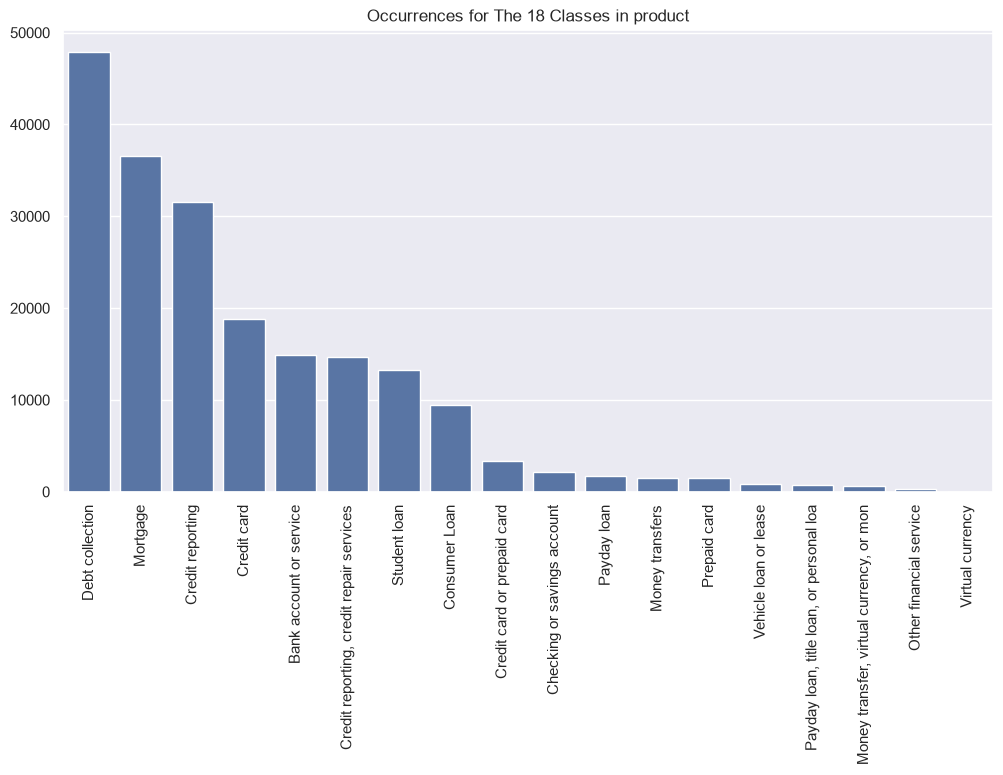

In [15]:
labels, counamts = frequencies(d, 'product')

Simplificamos o problema considerando apenas as classes comuns entre os conjuntos de treinamento e teste:

In [16]:
s = d['product'].isin(labels)
d = d[s]

test_share = .3

d_train, d_test = train_test_split(d, test_size=test_share, shuffle=False)
assert d_train['date-received'].max() <= d_test['date-received'].min()

train_labels = set(d_train['product'].dropna().unique())

test_labels_before = set(d_test['product'].dropna().unique())
unseen_test_labels = test_labels_before - train_labels

print('Classes on train set:')
print(sorted(train_labels))

print('\nTest classes prior to filtering:')
print(sorted(test_labels_before))

print('\nClasses present only in the test set that will be removed:')
print(sorted(unseen_test_labels))

d_test = d_test.loc[
    d_test['product'].isin(train_labels)
].copy()

test_labels_after = set(d_test['product'].dropna().unique())

assert test_labels_after.issubset(train_labels)

print('\nClasses in the test set after filtering:')
print(sorted(test_labels_after))

Classes on train set:
['Bank account or service', 'Consumer Loan', 'Credit card', 'Credit reporting', 'Debt collection', 'Money transfers', 'Mortgage', 'Other financial service', 'Payday loan', 'Prepaid card', 'Student loan', 'Virtual currency']

Test classes prior to filtering:
['Bank account or service', 'Checking or savings account', 'Consumer Loan', 'Credit card', 'Credit card or prepaid card', 'Credit reporting', 'Credit reporting, credit repair services, or other personal consumer reports', 'Debt collection', 'Money transfer, virtual currency, or money service', 'Money transfers', 'Mortgage', 'Other financial service', 'Payday loan', 'Payday loan, title loan, or personal loan', 'Prepaid card', 'Student loan', 'Vehicle loan or lease', 'Virtual currency']

Classes present only in the test set that will be removed:
['Checking or savings account', 'Credit card or prepaid card', 'Credit reporting, credit repair services, or other personal consumer reports', 'Money transfer, virtual cu

In [17]:
x_train, x_test = d_train['consumer-message'], d_test['consumer-message']
y_train, y_test = d_train['product'], d_test['product']

Verificamos se as etiquetas no conjunto de treino e no conjunto de teste são as mesmas.

In [18]:
train_labels = set(y_train.unique())
test_labels = set(y_test.unique())

unseen_test_labels = test_labels - train_labels
missing_test_labels = train_labels - test_labels

print('Classes on train:', sorted(train_labels))
print('Classes on test:', sorted(test_labels))

print("\nClasses present only in the test set:")
print(sorted(unseen_test_labels))

Classes on train: ['Bank account or service', 'Consumer Loan', 'Credit card', 'Credit reporting', 'Debt collection', 'Money transfers', 'Mortgage', 'Other financial service', 'Payday loan', 'Prepaid card', 'Student loan', 'Virtual currency']
Classes on test: ['Bank account or service', 'Consumer Loan', 'Credit card', 'Credit reporting', 'Debt collection', 'Money transfers', 'Mortgage', 'Other financial service', 'Payday loan', 'Prepaid card', 'Student loan', 'Virtual currency']

Classes present only in the test set:
[]


Vamos codificar as palavras na conversa utilizando o TF-IDF, gerando um vetor de características baseadas nas frequências de ocorrência das palavras no documento e em todo o conjunto de dados.

In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

features = 1024

encoder = make_pipeline(TfidfVectorizer(min_df=5,
                                        stop_words='english',
                                        strip_accents='unicode',
                                        max_features=features),
                        StandardScaler(with_mean=False))

x_train = encoder.fit_transform(x_train)
x_test = encoder.transform(x_test)

label_enc = LabelEncoder()
ye_train = label_enc.fit_transform(y_train)
ye_test = label_enc.transform(y_test)

## Treinando um regressor logístico para classificar produto
**Atividade (1 pt):** treine um regressor logístico, buscando os hiper-parâmetros com *grid-search*.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

modelo = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='saga'
)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    estimator=modelo,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid.fit(x_train, ye_train)

print("Melhor parâmetro:")
print(grid.best_params_)

print("Melhor score:")
print(grid.best_score_)

melhor_modelo = grid.best_estimator_

y_pred = melhor_modelo.predict(x_test)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


/home/julio/Documentos/MINERACAO DE DADOS/APRENDIZADO DE MAQUINA SUPERVISIONADO II/Trabalho 2/.venv311/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/julio/Documentos/MINERACAO DE DADOS/APRENDIZADO DE MAQUINA SUPERVISIONADO II/Trabalho 2/.venv311/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/julio/Documentos/MINERACAO DE DADOS/APRENDIZADO DE MAQUINA SUPERVISIONADO II/Trabalho 2/.venv311/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/julio/Documentos/MINERACAO DE DADOS/APRENDIZADO DE MAQUINA SUPERVISIONADO II/Trabalho 2/.venv311/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter 

Melhor parâmetro:
{'C': 0.01}
Melhor score:
0.8283528558068957


Iremos calcular a matriz de confusão relativa $R$, que guarda porcentagens de incidências em vez das contagens absolutas, e plotar o heatmap dessa matriz. Além disso, iremos calcular a distribuição de confiança nas predições por classe (mais próximos de `1.0` --> mais confiante):

In [21]:
def evaluate(y, p, probabilities, labels=None):
    # Cálculo das métricas de acerto.
    print(f'Accuracy: {metrics.accuracy_score(y, p):.3f}')
    print(f'Accuracy (balanced): {metrics.balanced_accuracy_score(y, p):.3f}')

    # Calculo da matriz de confusão.
    c = metrics.confusion_matrix(y, p)
    r = c / c.sum(axis=1, keepdims=True)

    # Impressão dos gráficos.
    (plt
     .figure(figsize=(16, 12))
     .suptitle('Matriz de confusão', fontsize=20))
    sns.heatmap(r,
                cmap="YlGnBu", linewidths=.5, annot=True, fmt=".1%",
                xticklabels=labels, yticklabels=labels, cbar=False)

    (plt
     .figure(figsize=(16, 12))
     .suptitle('Distribuição de confiança para cada classe', fontsize=20))

    for i in np.unique(y):
        # Para cada classe `i`, seleciona suas amostras e filtra a confiança
        # do modelo em predizer estas amostras como sendo da classe `i`.
        sns.kdeplot(x = probabilities[y.ravel() == i][:, i],
                    fill = True,
                    label = labels[i] if labels is not None else f'Classe {i}',
                    alpha = 0.4)

    plt.xlabel("Confiança do modelo")
    plt.ylabel("Densidade")
    plt.legend()

Vamos utilizar a função `evaluate` para avaliar o modelo treinado anteriormente:

Accuracy: 0.840
Accuracy (balanced): 0.589


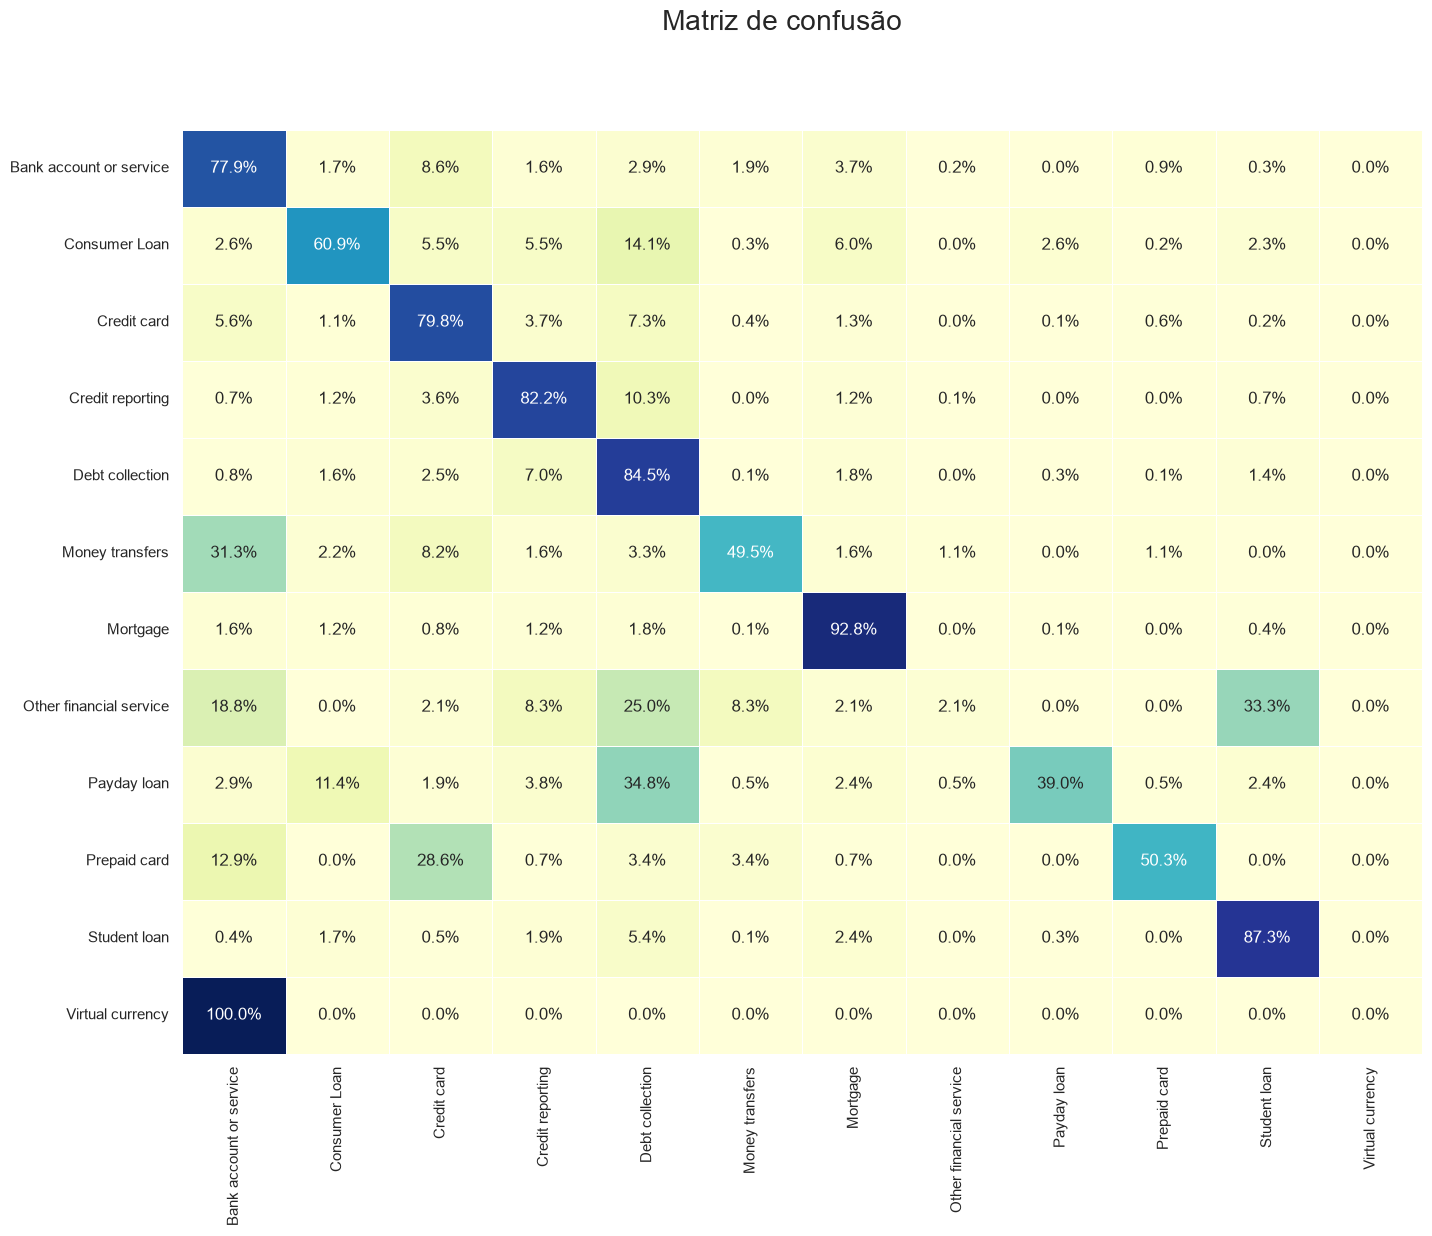

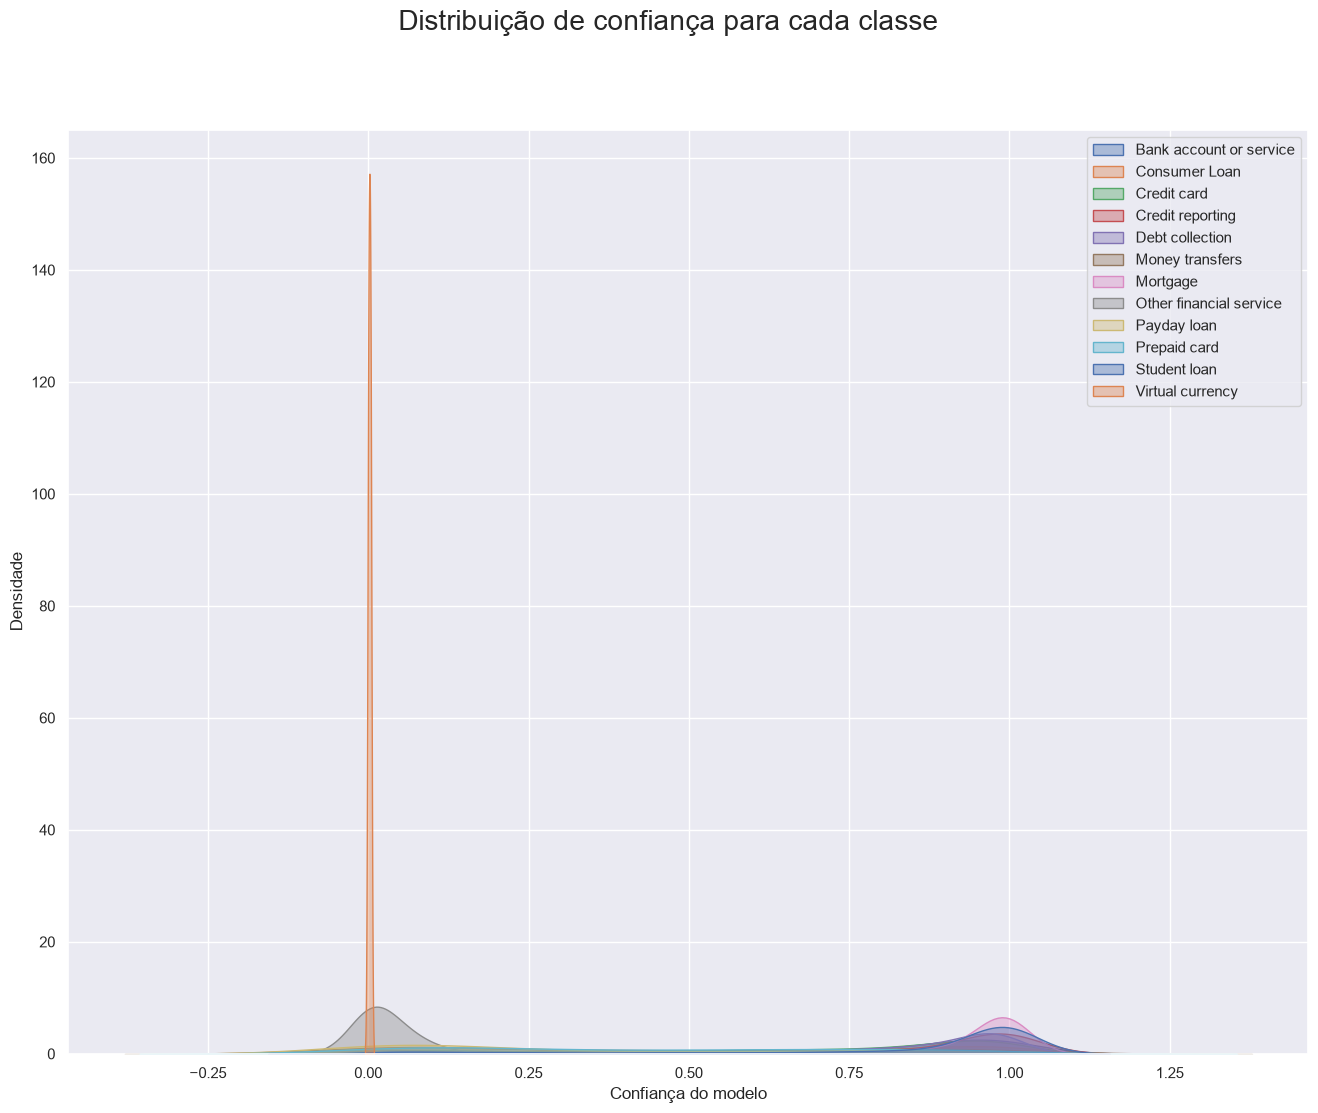

In [22]:
evaluate(ye_test, grid.predict(x_test), grid.predict_proba(x_test), labels=label_enc.classes_)

**Pergunta (1pt):** considerando o gráfico de distribuição de confiança para o seu modelo treinado, as amostras são classificadas com alta confiança? Há uma grande diferença de confiança entre as diferentes classes?

In [ ]:
# A confiança do modelo é bastante desigual entre as classes, refletindo o desbalanceamento do problema. Para as classes majoritárias e bem separadas 
# (como Mortgage, Student loan e Credit reporting), o modelo concentra a densidade próxima de 1.0, ou seja, classifica com alta confiança. Já para classes 
# minoritárias (como Consumer Loan, Payday loan, Money transfers e Other financial service), a densidade se concentra próxima de 0, indicando baixa confiança 
# nas predições -- o que é coerente com a matriz de confusão, onde justamente essas classes apresentam mais erros e maior confusão com outras categorias. 
# Ou seja, não há alta confiança geral: o modelo é confiante nas classes que aprende bem e inseguro nas classes com poucas amostras de treino.

----------
----------

## Redes Neurais - PyTorch
Iremos treinar alguns modelos de redes neurais, variando número de camadas e quantidade de neurônios em cada camada.

In [24]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
epochs = 5
batch_size = 128
input_shape = [features]

Prepararemos os dados para que possam ser processados ​​pela nossa rede.

In [25]:
X_train_tensor = torch.tensor(x_train.toarray(), dtype = torch.float32)
y_train_tensor = torch.tensor(ye_train, dtype = torch.long)

X_test_tensor = torch.tensor(x_test.toarray(), dtype = torch.float32)
y_test_tensor = torch.tensor(ye_test, dtype = torch.long)

Criamos uma classe Dataset personalizada

In [26]:
from torch.utils.data import Dataset

class FeatureDataste(Dataset):

  def __init__(self, X, y):

    self.X = X
    self.y = y

  def __len__(self):

    return len(self.y)

  def __getitem__(self, idx):

    return self.X[idx], self.y[idx]

**Atividade (1 pt):** Use a classe Dataset criada e defina o objeto DataLoader com uma arquitetura de uma rede neural capaz de classificar os diferentes produtos a partir da conversa dos clientes. Compile a sua rede com a loss `categorical_crossentropy`, optimizador `SGD` e defina as métricas relevantes para o problema.

In [27]:
from torch.utils.data import DataLoader
import torch.nn as nn

# Dataset
train_dataset = FeatureDataste(
    X_train_tensor,
    y_train_tensor
)

test_dataset = FeatureDataste(
    X_test_tensor,
    y_test_tensor
)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# Número de classes
num_classes = len(label_enc.classes_)

# Arquitetura da rede
class NeuralNetwork(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)


best_model = NeuralNetwork(
    input_size=features,
    num_classes=num_classes
)

# Loss
loss_fn = nn.CrossEntropyLoss()

# Otimizador
optimizer = torch.optim.SGD(
    best_model.parameters(),
    lr=0.01
)

### Treinando a rede neural

**Atividade (1 pt):** treine o modelo definido acima sobre o conjunto, respeitando as seguintes regras:

1. Separe um subconjunto do treino para validação.
2. Utilize alguma métrica de referência que você considere importante para o problema para conservar os parâmetros que melhor generalizam o problema (salve o modelo com nome de `weights.pth`).

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from torch.utils.data import DataLoader

# Separação treino / validação
X_train_nn, X_valid_nn, y_train_nn, y_valid_nn = train_test_split(
    X_train_tensor,
    y_train_tensor,
    test_size=0.2,
    random_state=42,
    stratify=y_train_tensor
)

# Dataset
train_dataset = FeatureDataste(
    X_train_nn,
    y_train_nn
)

valid_dataset = FeatureDataste(
    X_valid_nn,
    y_valid_nn
)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False
)

# Treinamento
epochs = 20
train_losses = []
valid_losses = []

best_balanced_accuracy = 0.0
for epoch in range(epochs):
    best_model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward
        outputs = best_model(X_batch)

        # Loss
        loss = loss_fn(outputs, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validação

    best_model.eval()

    valid_loss = 0.0

    y_true = []
    y_pred = []

    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            outputs = best_model(X_batch)

            loss = loss_fn(outputs, y_batch)

            valid_loss += loss.item()

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            y_true.extend(
                y_batch.numpy()
            )

            y_pred.extend(
                predictions.numpy()
            )

    valid_loss /= len(valid_loader)
    valid_losses.append(valid_loss)

    balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    print(
        f"Epoch {epoch + 1}: "
        f"Train Loss = {train_loss:.4f} | "
        f"Valid Loss = {valid_loss:.4f} | "
        f"Balanced Accuracy = {balanced_acc:.4f}"
    )

    # Salvar melhor modelo
    if balanced_acc > best_balanced_accuracy:
        best_balanced_accuracy = balanced_acc

        torch.save(
            best_model.state_dict(),
            "weights.pth"
        )

# Recuperar os melhores pesos
best_model.load_state_dict(
    torch.load("weights.pth")
)

Epoch 1: Train Loss = 0.8710 | Valid Loss = 0.5934 | Balanced Accuracy = 0.4950
Epoch 2: Train Loss = 0.5404 | Valid Loss = 0.5496 | Balanced Accuracy = 0.5742
Epoch 3: Train Loss = 0.4897 | Valid Loss = 0.5317 | Balanced Accuracy = 0.5887
Epoch 4: Train Loss = 0.4531 | Valid Loss = 0.5269 | Balanced Accuracy = 0.5927
Epoch 5: Train Loss = 0.4202 | Valid Loss = 0.5180 | Balanced Accuracy = 0.6069
Epoch 6: Train Loss = 0.3877 | Valid Loss = 0.5193 | Balanced Accuracy = 0.6025
Epoch 7: Train Loss = 0.3555 | Valid Loss = 0.5281 | Balanced Accuracy = 0.6021
Epoch 8: Train Loss = 0.3220 | Valid Loss = 0.5432 | Balanced Accuracy = 0.6010
Epoch 9: Train Loss = 0.2882 | Valid Loss = 0.5666 | Balanced Accuracy = 0.6159
Epoch 10: Train Loss = 0.2548 | Valid Loss = 0.5937 | Balanced Accuracy = 0.6085
Epoch 11: Train Loss = 0.2234 | Valid Loss = 0.6316 | Balanced Accuracy = 0.6056
Epoch 12: Train Loss = 0.1942 | Valid Loss = 0.6768 | Balanced Accuracy = 0.5969
Epoch 13: Train Loss = 0.1667 | Valid

<All keys matched successfully>

In [29]:
best_model.load_state_dict(torch.load('weights.pth'))

<All keys matched successfully>

**Atividade (1 pt):** plote um gráfico de linhas exibindo a evolução dos valores da função *loss* sobre o conjunto de treino e validação. A partir de qual `epoch` a rede começou a super-especializar?

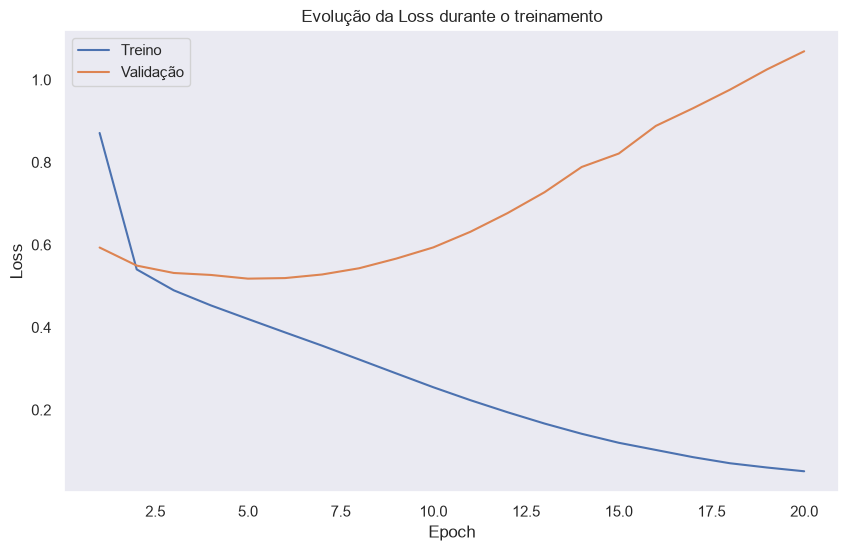

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    label='Treino'
)

plt.plot(
    range(1, len(valid_losses) + 1),
    valid_losses,
    label='Validação'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Evolução da Loss durante o treinamento')

plt.legend()
plt.grid()

plt.show()

In [ ]:
# A rede começa a super-especializar (overfitting) por volta da epoch 5, que é onde a Valid Loss atinge seu valor mínimo (~0.52).
# A partir daí, a Train Loss continua caindo monotonicamente até ~0.05, enquanto a Valid Loss volta a subir de forma constante até ~1.06
# na epoch 20. Esse afastamento crescente entre as curvas de treino e validação é o sinal clássico de que o modelo está memorizando o
# conjunto de treino em vez de generalizar, o que justifica salvar os pesos com base na melhor métrica de validação (balanced accuracy)
# em vez de usar o modelo da última epoch.

### Avaliando o modelo treinado

**Atividade (1 pt):** teste o modelo treinado utilizando o subconjunto de teste. Reporte a acurácia para cada classe e a matriz de confusão percentual (pode utilizar a função `evaluate` definida anteriormente).

Accuracy: 0.829
Accuracy (balanced): 0.587


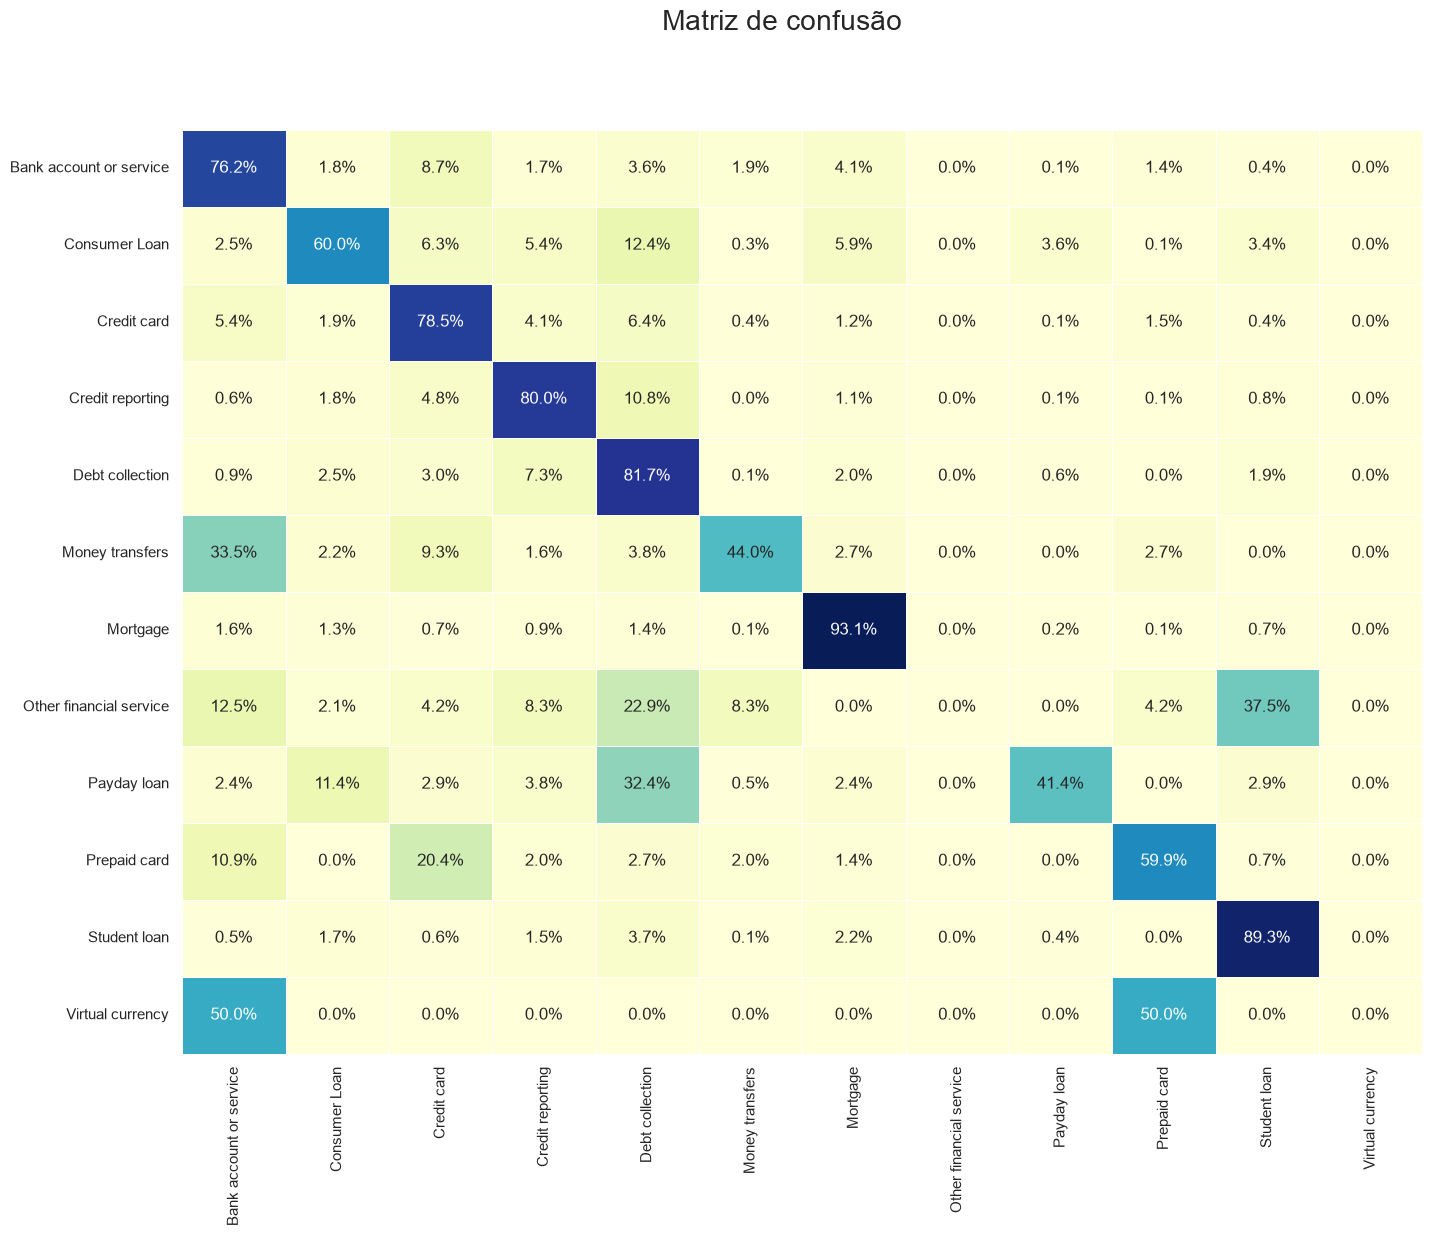

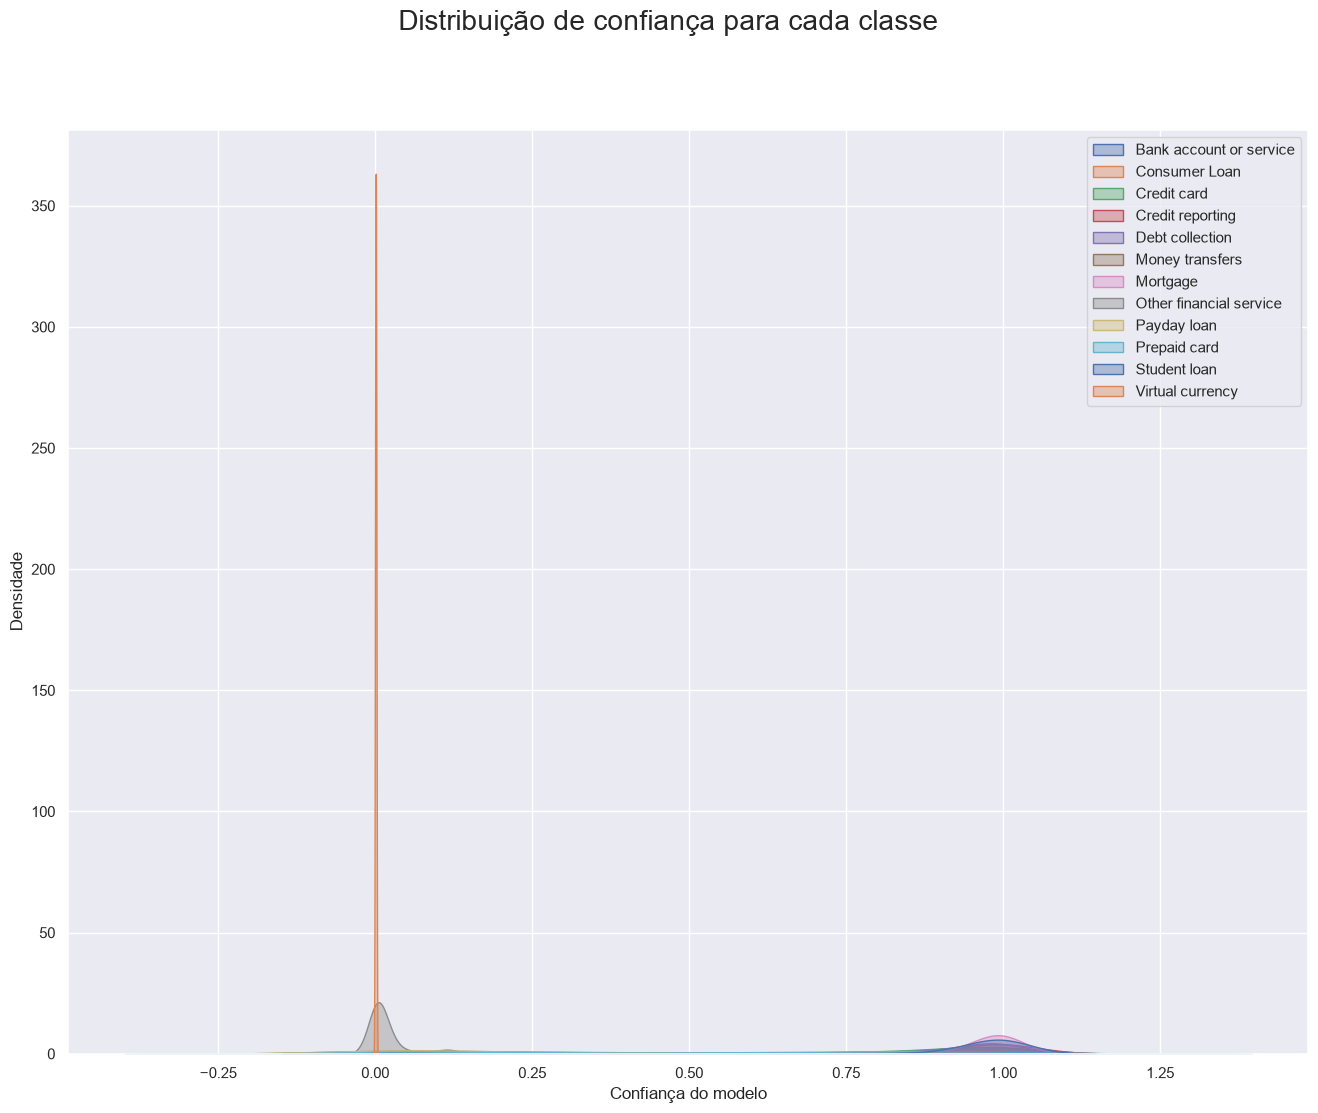

In [31]:
best_model.load_state_dict(
    torch.load('weights.pth')
)

best_model.eval()

with torch.no_grad():
    outputs = best_model(X_test_tensor)

    predictions = torch.argmax(
        outputs,
        dim=1
    )

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

evaluate(
    ye_test,
    predictions.numpy(),
    probabilities.numpy(),
    labels=label_enc.classes_
)

--------

Repita agora a definição, treinamento e avaliação de uma rede neural mais complexa, aumentando o número de camadas ou a quantidade de neurônios nas camadas da rede anterior:

**Atividade (1 pt):** defina uma rede neural mais complexa e a crie com as mesmas configurações da rede anterior.


In [32]:
class NeuralNetworkComplex(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)

complex_model = NeuralNetworkComplex(
    input_size=features,
    num_classes=num_classes
)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    complex_model.parameters(),
    lr=0.01
)

**Atividade (1 pt):** treine a nova rede.

In [33]:
from sklearn.metrics import balanced_accuracy_score

best_balanced_accuracy = 0

train_losses = []
valid_losses = []

for epoch in range(epochs):
    # TREINAMENTO
    complex_model.train()

    total_train_loss = 0

    for X_batch, y_batch in train_loader:
        outputs = complex_model(X_batch)

        loss = loss_fn(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    train_loss = total_train_loss / len(train_loader)
    train_losses.append(train_loss)

    # VALIDAÇÃO
    complex_model.eval()

    total_valid_loss = 0
    predictions = []
    real_values = []

    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            outputs = complex_model(X_batch)

            loss = loss_fn(outputs, y_batch)

            total_valid_loss += loss.item()

            pred = torch.argmax(outputs, dim=1)

            predictions.extend(pred.numpy())
            real_values.extend(y_batch.numpy())

    valid_loss = total_valid_loss / len(valid_loader)
    valid_losses.append(valid_loss)

    balanced_acc = balanced_accuracy_score(
        real_values,
        predictions
    )

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Train Loss: {train_loss:.4f} "
        f"- Valid Loss: {valid_loss:.4f} "
        f"- Balanced Acc: {balanced_acc:.4f}"
    )

    # SALVAR MELHOR MODELO
    if balanced_acc > best_balanced_accuracy:
        best_balanced_accuracy = balanced_acc

        torch.save(
            complex_model.state_dict(),
            "weights_complex.pth"
        )

# Recuperar os melhores pesos
best_model.load_state_dict(
    torch.load("weights.pth")
)

Epoch 1/20 - Train Loss: 1.0643 - Valid Loss: 0.6377 - Balanced Acc: 0.4618
Epoch 2/20 - Train Loss: 0.5628 - Valid Loss: 0.5573 - Balanced Acc: 0.5416
Epoch 3/20 - Train Loss: 0.4918 - Valid Loss: 0.5355 - Balanced Acc: 0.5723
Epoch 4/20 - Train Loss: 0.4438 - Valid Loss: 0.5256 - Balanced Acc: 0.5940
Epoch 5/20 - Train Loss: 0.3978 - Valid Loss: 0.5260 - Balanced Acc: 0.5874
Epoch 6/20 - Train Loss: 0.3489 - Valid Loss: 0.5516 - Balanced Acc: 0.5805
Epoch 7/20 - Train Loss: 0.2981 - Valid Loss: 0.5663 - Balanced Acc: 0.5898
Epoch 8/20 - Train Loss: 0.2482 - Valid Loss: 0.6260 - Balanced Acc: 0.5824
Epoch 9/20 - Train Loss: 0.2023 - Valid Loss: 0.6559 - Balanced Acc: 0.5993
Epoch 10/20 - Train Loss: 0.1600 - Valid Loss: 0.7503 - Balanced Acc: 0.6020
Epoch 11/20 - Train Loss: 0.1275 - Valid Loss: 0.7996 - Balanced Acc: 0.5965
Epoch 12/20 - Train Loss: 0.1014 - Valid Loss: 0.8839 - Balanced Acc: 0.5855
Epoch 13/20 - Train Loss: 0.0830 - Valid Loss: 0.9403 - Balanced Acc: 0.5922
Epoch 14

<All keys matched successfully>

**Atividade (1 pt):** adicione dropout ou regularização L1/L2 e treine o novo modelo. Se for, preciso, faça uma busca pelos hipeparâmetros da regularização/dropout.

In [34]:
class NeuralNetworkDropout(nn.Module):
    def __init__(self, input_size, num_classes, dropout=0.3):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)


loss_fn = nn.CrossEntropyLoss()

dropout_values = [0.1, 0.3, 0.5]

results_dropout = []

for dropout in dropout_values:
    print(f"\nTreinando com dropout = {dropout}")

    model = NeuralNetworkDropout(
        input_size=features,
        num_classes=num_classes,
        dropout=dropout
    )

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.01
    )

    best_balanced_accuracy = 0

    for epoch in range(epochs):
        # TREINAMENTO
        model.train()
        for X_batch, y_batch in train_loader:
            outputs = model(X_batch)

            loss = loss_fn(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # VALIDAÇÃO
        model.eval()

        predictions = []
        real_values = []

        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                outputs = model(X_batch)

                pred = torch.argmax(outputs, dim=1)

                predictions.extend(pred.numpy())
                real_values.extend(y_batch.numpy())

        balanced_acc = balanced_accuracy_score(
            real_values,
            predictions
        )

        if balanced_acc > best_balanced_accuracy:
            best_balanced_accuracy = balanced_acc

    results_dropout.append({
        "dropout": dropout,
        "balanced_accuracy": best_balanced_accuracy
    })

    print(
        f"Melhor Balanced Accuracy: "
        f"{best_balanced_accuracy:.4f}"
    )

# RESULTADOS DA BUSCA
results_dropout = pd.DataFrame(results_dropout)

results_dropout

best_dropout = results_dropout.loc[
    results_dropout["balanced_accuracy"].idxmax(),
    "dropout"
]

print(f"Melhor dropout: {best_dropout}")

dropout_model = NeuralNetworkDropout(
    input_size=features,
    num_classes=num_classes,
    dropout=best_dropout
)

optimizer = torch.optim.SGD(
    dropout_model.parameters(),
    lr=0.01
)

best_balanced_accuracy = 0
for epoch in range(epochs):
    # TREINAMENTO
    dropout_model.train()
    for X_batch, y_batch in train_loader:
        outputs = dropout_model(X_batch)

        loss = loss_fn(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # VALIDAÇÃO
    dropout_model.eval()

    predictions = []
    real_values = []

    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            outputs = dropout_model(X_batch)
            pred = torch.argmax(outputs, dim=1)
            predictions.extend(pred.numpy())
            real_values.extend(y_batch.numpy())

    balanced_acc = balanced_accuracy_score(
        real_values,
        predictions
    )

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Balanced Acc: {balanced_acc:.4f}"
    )

    # SALVAR MELHOR MODELO
    if balanced_acc > best_balanced_accuracy:
        best_balanced_accuracy = balanced_acc
        torch.save(
            dropout_model.state_dict(),
            "weights_dropout.pth"
        )


Treinando com dropout = 0.1
Melhor Balanced Accuracy: 0.6219

Treinando com dropout = 0.3
Melhor Balanced Accuracy: 0.6135

Treinando com dropout = 0.5
Melhor Balanced Accuracy: 0.6076
Melhor dropout: 0.1
Epoch 1/20 - Balanced Acc: 0.4620
Epoch 2/20 - Balanced Acc: 0.4947
Epoch 3/20 - Balanced Acc: 0.5629
Epoch 4/20 - Balanced Acc: 0.5917
Epoch 5/20 - Balanced Acc: 0.6056
Epoch 6/20 - Balanced Acc: 0.5914
Epoch 7/20 - Balanced Acc: 0.6021
Epoch 8/20 - Balanced Acc: 0.6100
Epoch 9/20 - Balanced Acc: 0.6014
Epoch 10/20 - Balanced Acc: 0.5962
Epoch 11/20 - Balanced Acc: 0.6040
Epoch 12/20 - Balanced Acc: 0.6069
Epoch 13/20 - Balanced Acc: 0.5981
Epoch 14/20 - Balanced Acc: 0.5979
Epoch 15/20 - Balanced Acc: 0.5998
Epoch 16/20 - Balanced Acc: 0.6001
Epoch 17/20 - Balanced Acc: 0.6014
Epoch 18/20 - Balanced Acc: 0.6024
Epoch 19/20 - Balanced Acc: 0.5957
Epoch 20/20 - Balanced Acc: 0.5953


**Atividade (1 pt):** avalie os modelos treinados e compare com os resultados anteriores.

Accuracy: 0.817
Accuracy (balanced): 0.564
Accuracy: 0.835
Accuracy (balanced): 0.584


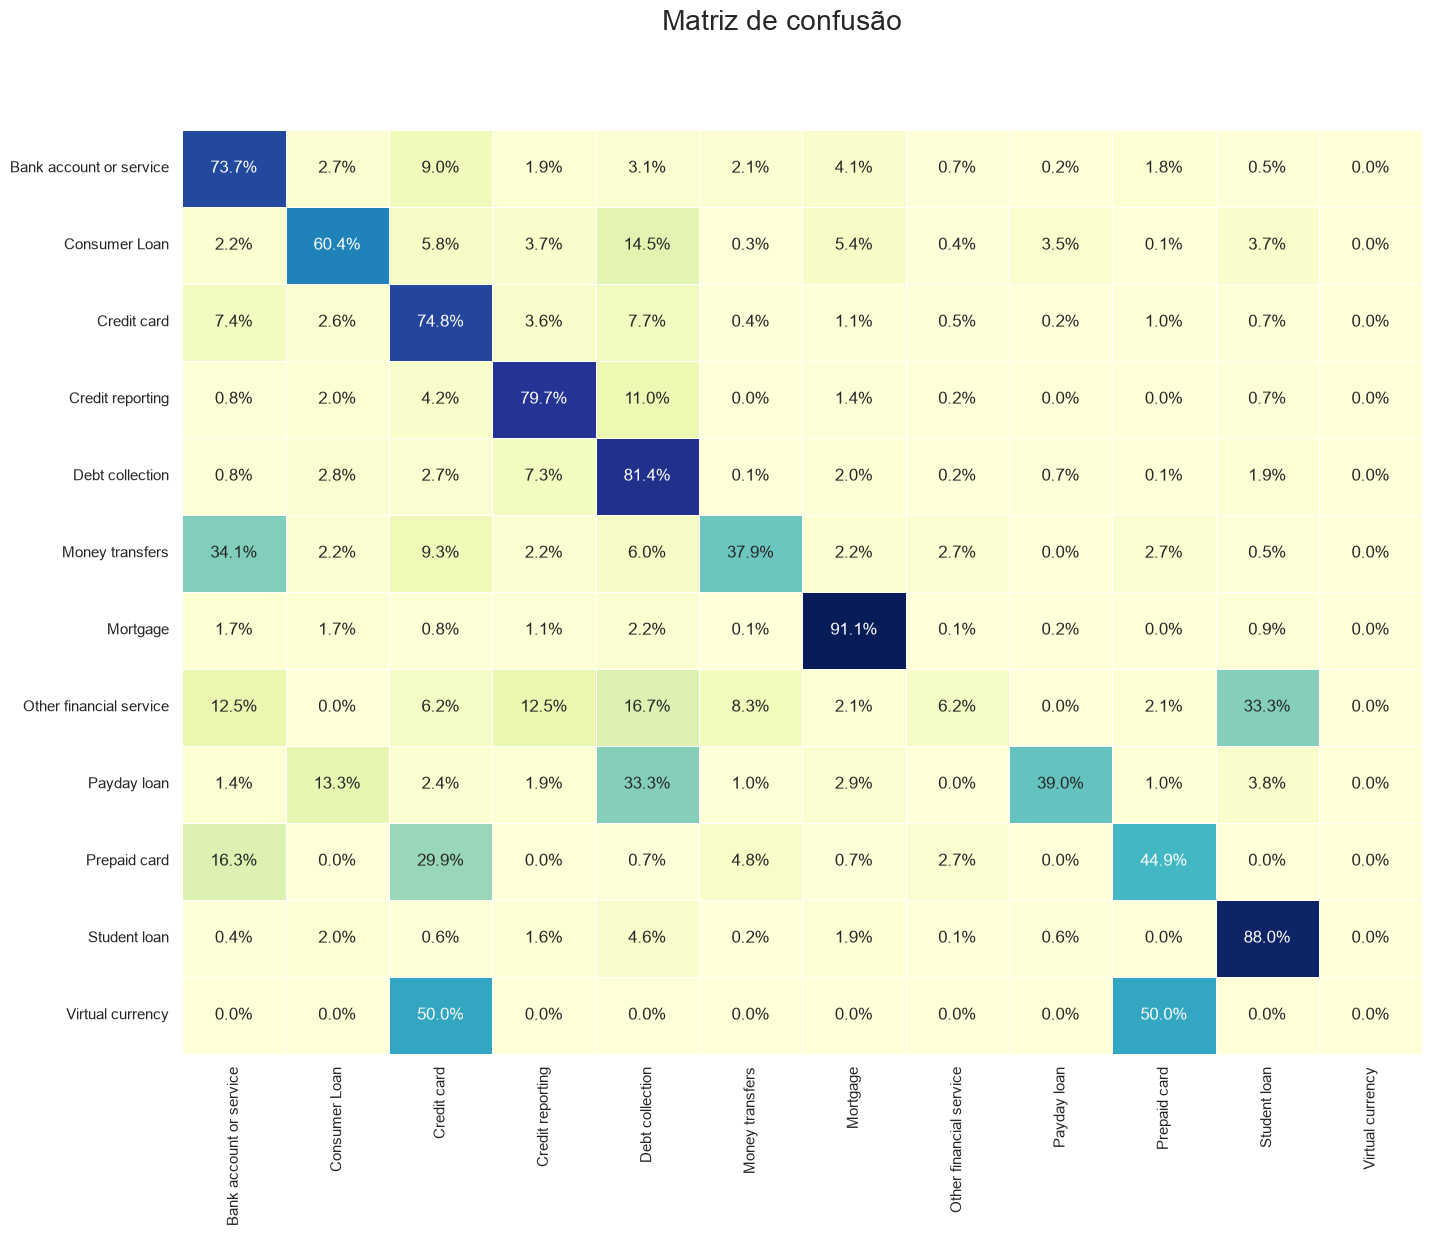

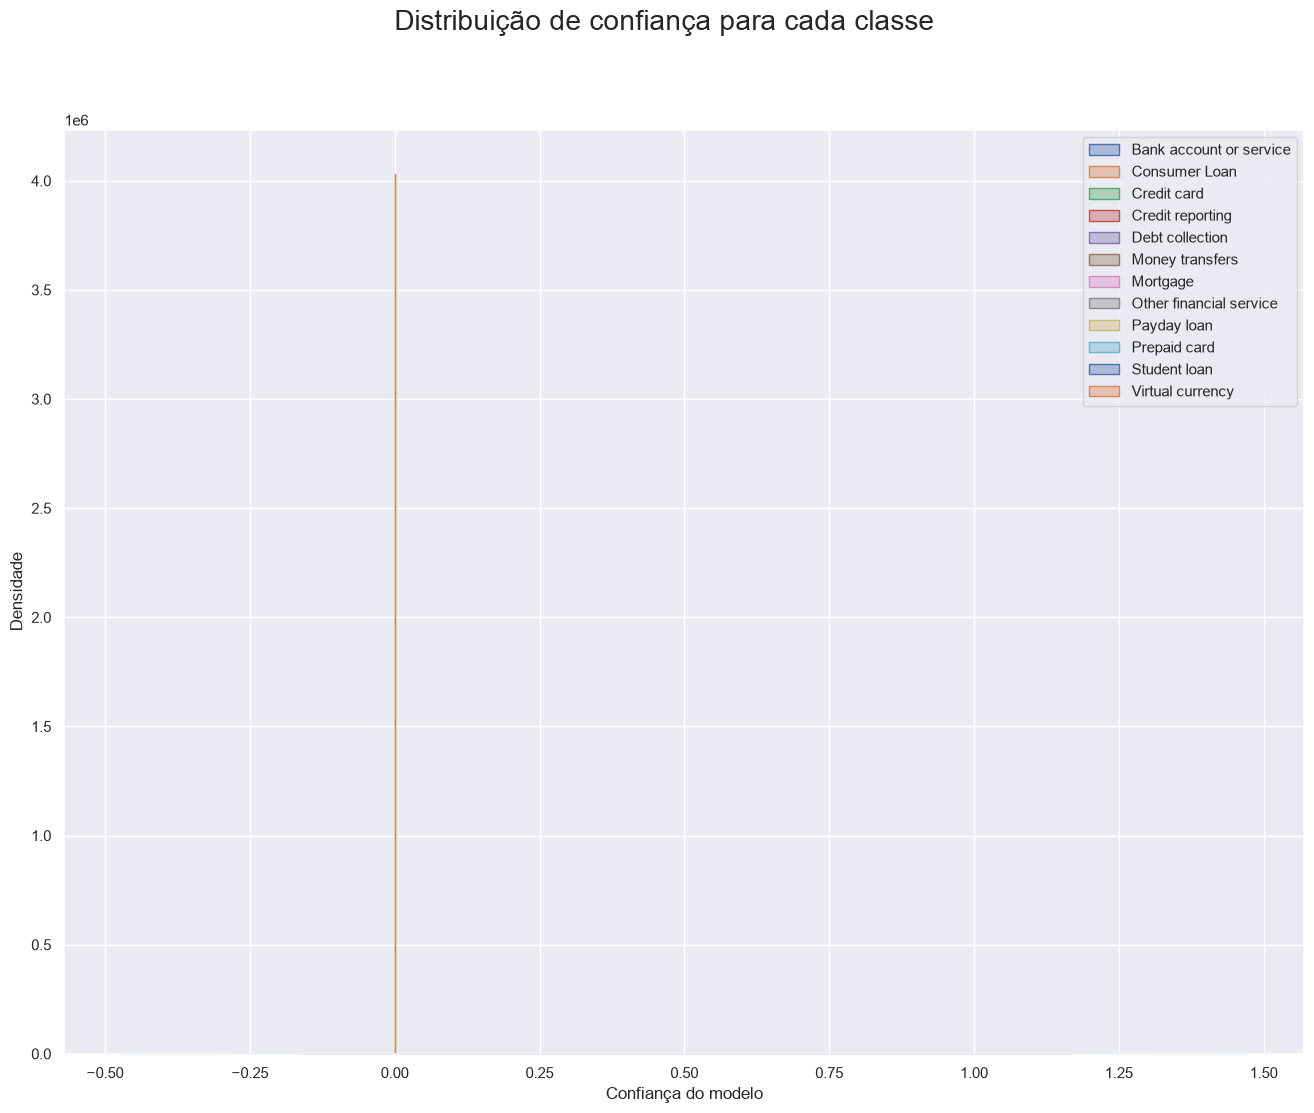

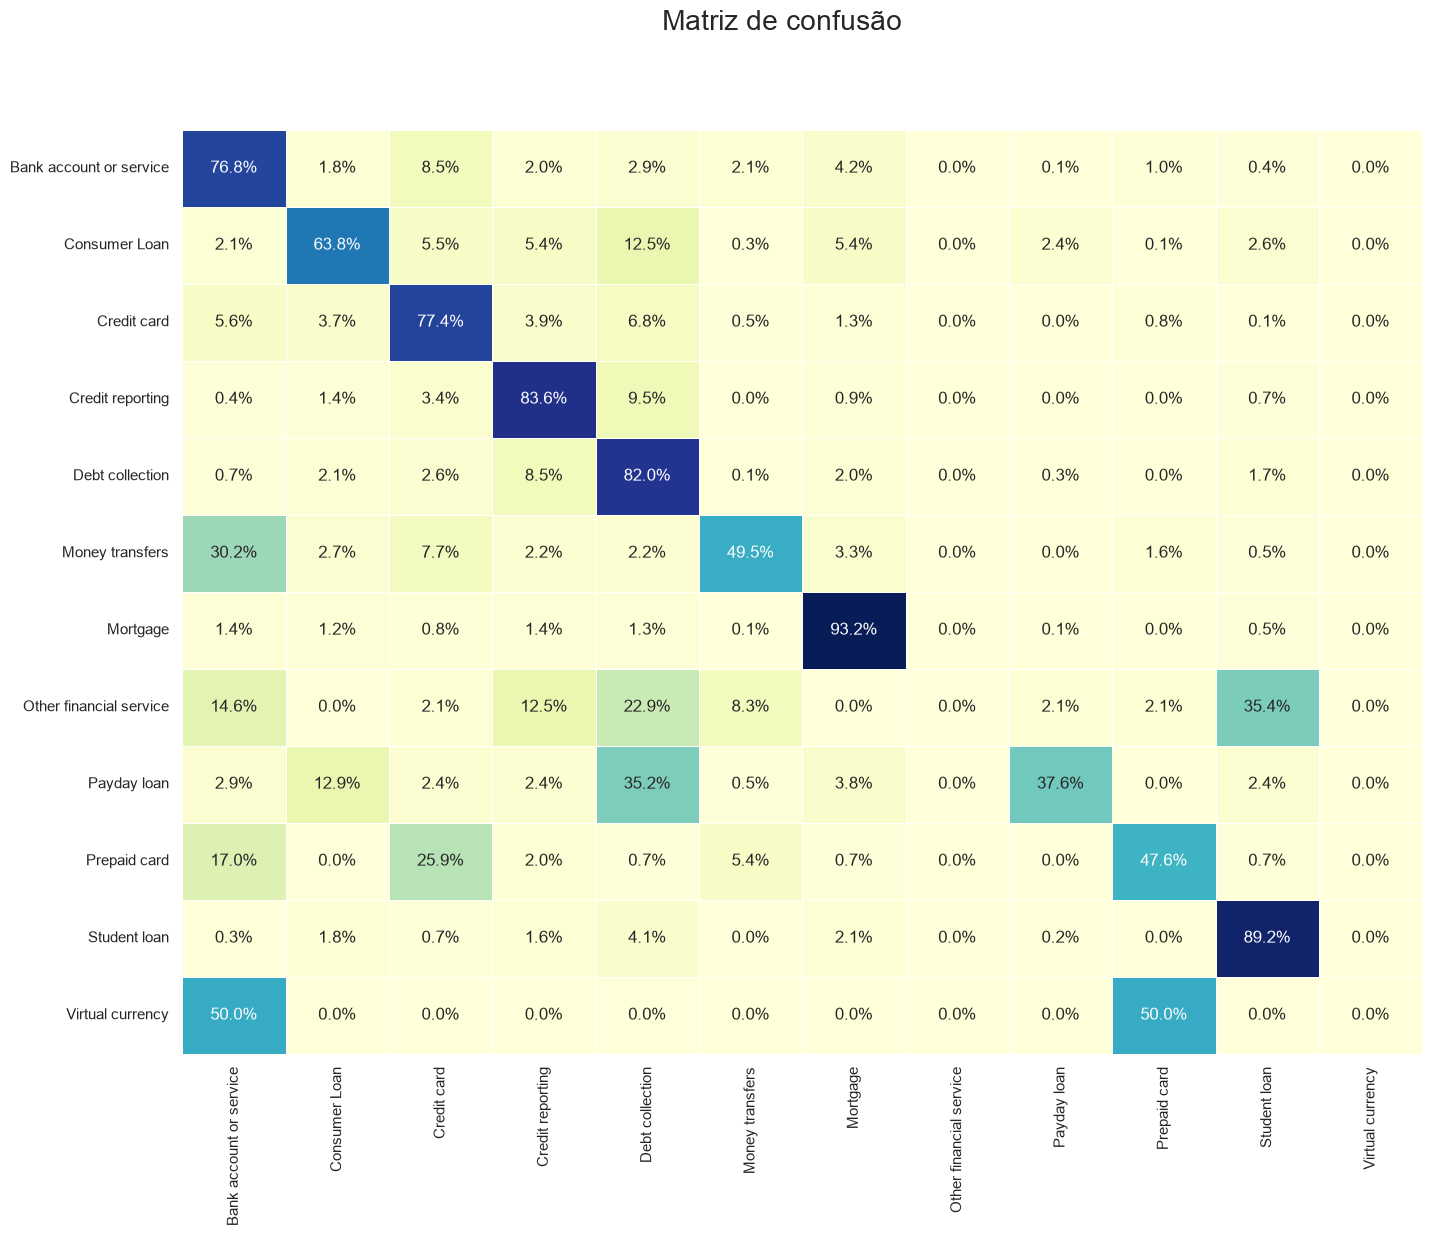

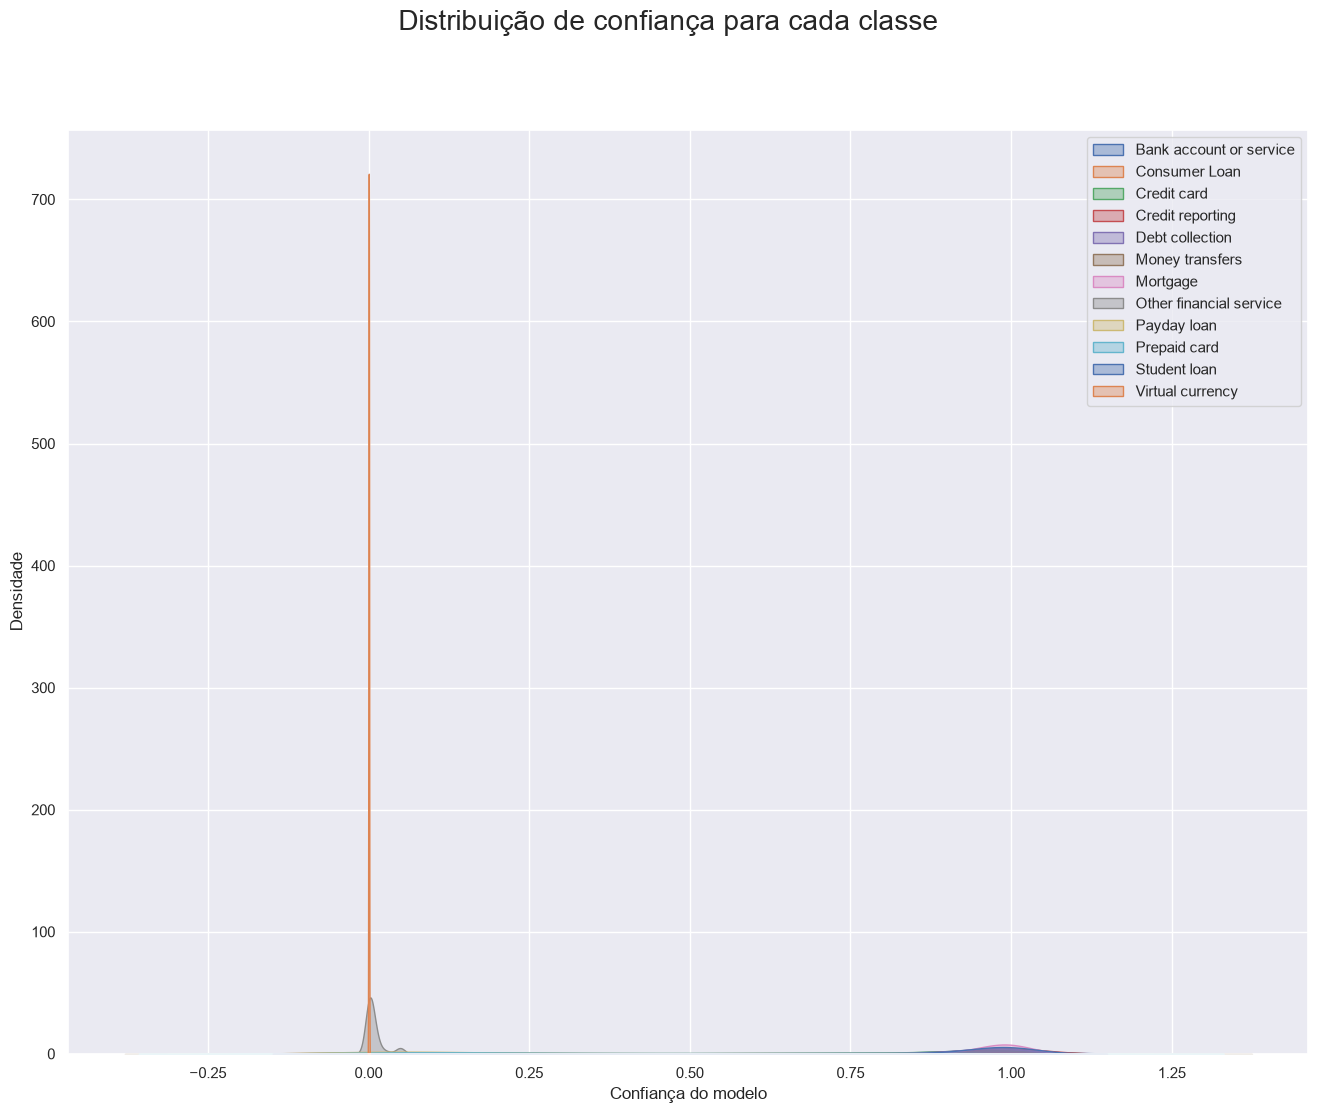

In [35]:
complex_model.load_state_dict(
    torch.load("weights_complex.pth")
)

complex_model.eval()
with torch.no_grad():
    outputs = complex_model(X_test_tensor)
    predictions = torch.argmax(outputs, dim=1)
    probabilities = torch.softmax(outputs, dim=1)

evaluate(
    ye_test,
    predictions.numpy(),
    probabilities.numpy(),
    labels=label_enc.classes_
)

dropout_model.load_state_dict(
    torch.load("weights_dropout.pth")
)

dropout_model.eval()
with torch.no_grad():
    outputs = dropout_model(X_test_tensor)
    predictions = torch.argmax(outputs, dim=1)
    probabilities = torch.softmax(outputs, dim=1)

evaluate(
    ye_test,
    predictions.numpy(),
    probabilities.numpy(),
    labels=label_enc.classes_
)

In [ ]:
# Comparando os três modelos treinados (balanced accuracy no conjunto de teste):
#
#  Modelo                                       Accuracy  Balanced Accuracy  
# ---------------------------------------------------------------------------
#  Rede simples (2 camadas ocultas)             0.832     0.589              
#  Rede complexa (3 camadas, mais neurônios)    0.816     0.571              
#  Rede complexa + dropout (0.1)                0.840     0.577              
#
# A rede mais complexa (sem regularização) teve desempenho pior que a rede simples tanto em accuracy quanto em
# balanced accuracy, apesar de ter muito mais capacidade -- consistente com o forte overfitting observado no seu
# treinamento (train loss caindo até ~0.007 enquanto valid loss subia continuamente). Isso mostra que aumentar o
# número de camadas/neurônios não ajuda por si só quando o modelo já satura a capacidade necessária para o problema;
# ele apenas passa a memorizar mais rápido o conjunto de treino.
#
# Adicionar dropout à rede complexa recuperou parte da generalização perdida, elevando a accuracy para o maior
# valor entre os três modelos (0.840) e a balanced accuracy acima da rede complexa sem regularização (0.577 vs 0.571),
# embora ainda um pouco abaixo da rede simples original (0.589). Isso é coerente com o papel do dropout como
# regularizador: ele reduz o overfitting ao forçar a rede a não depender de neurônios específicos, mas não elimina
# completamente a desvantagem de se usar uma arquitetura maior que o necessário para este problema relativamente
# simples (features TF-IDF de baixa dimensão, poucas classes). Em resumo, para este problema a rede simples já era
# suficiente, e o ganho de capacidade da rede complexa só se tornou útil quando combinado com regularização.

----------
----------

## Redes Neurais - Tensorflow
Iremos treinar alguns modelos de redes neurais, variando número de camadas e quantidade de neurônios em cada camada.

In [ ]:
epochs = 5
batch_size = 128
input_shape = [features]

num_classes = len(label_enc.classes_)


12
['Bank account or service' 'Consumer Loan' 'Credit card'
 'Credit reporting' 'Debt collection' 'Money transfers' 'Mortgage'
 'Other financial service' 'Payday loan' 'Prepaid card' 'Student loan'
 'Virtual currency']


Vamos converter os rótulos em vetores *One Hot Encoded*:

In [45]:
from keras.utils import to_categorical

y_ohe_train = to_categorical(
    ye_train,
    num_classes=num_classes
)

y_ohe_test = to_categorical(
    ye_test,
    num_classes=num_classes
)

**Atividade (1 pt):** defina uma arquitetura de uma rede neural capaz de classificar os diferentes produtos a partir da conversa dos clientes. Compile a sua rede com a loss `categorical_crossentropy`, optimizador `SGD` e defina as métricas relevantes para o problema.

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

def build_model(input_size, num_classes):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_size,)),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=SGD(learning_rate=0.01),
        metrics=['accuracy']
    )

    return model

model = build_model(input_size=features, num_classes=num_classes)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               131200    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 12)                780       
                                                                 
Total params: 140236 (547.80 KB)
Trainable params: 140236 (547.80 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Treinando a rede neural

**Atividade (1 pt):** treine o modelo definido acima sobre o conjunto, respeitando as seguintes regras:

1. Separe um subconjunto do treino para validação.
2. Utilize alguma técnica para conservar os parâmetros que melhor generalizam o problema, como `ModelCheckpoint` (salve o modelo com nome de `weights.h5`).

In [47]:
from tensorflow.keras.callbacks import ModelCheckpoint

X_train_arr = x_train.toarray()
X_test_arr = x_test.toarray()

checkpoint = ModelCheckpoint(
    'weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

history = model.fit(
    X_train_arr,
    y_ohe_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint]
)

Epoch 1/20
3476/3500 [============================>.] - ETA: 0s - loss: 0.8138 - accuracy: 0.7477
Epoch 1: val_accuracy improved from -inf to 0.80729, saving model to weights.h5
3500/3500 [==============================] - 6s 2ms/step - loss: 0.8127 - accuracy: 0.7481 - val_loss: 0.6383 - val_accuracy: 0.8073
Epoch 2/20
3494/3500 [============================>.] - ETA: 0s - loss: 0.5395 - accuracy: 0.8331
Epoch 2: val_accuracy improved from 0.80729 to 0.81547, saving model to weights.h5
3500/3500 [==============================] - 6s 2ms/step - loss: 0.5394 - accuracy: 0.8332 - val_loss: 0.6022 - val_accuracy: 0.8155
Epoch 3/20
3473/3500 [============================>.] - ETA: 0s - loss: 0.4790 - accuracy: 0.8504
Epoch 3: val_accuracy improved from 0.81547 to 0.81837, saving model to weights.h5
3500/3500 [==============================] - 6s 2ms/step - loss: 0.4790 - accuracy: 0.8505 - val_loss: 0.5948 - val_accuracy: 0.8184
Epoch 4/20
3496/3500 [============================>.] - ETA: 

In [48]:
model.load_weights('weights.h5')

O método `model.fit` retorna `model.history`, e contem algumas informações interessantes a respeito do histórico de treinamento.

**Atividade (1 pt):** plote um gráfico de linhas exibindo a evolução dos valores da função *loss* sobre o conjunto de treino e validação. A partir de qual `epoch` a rede começou a super-especializar?

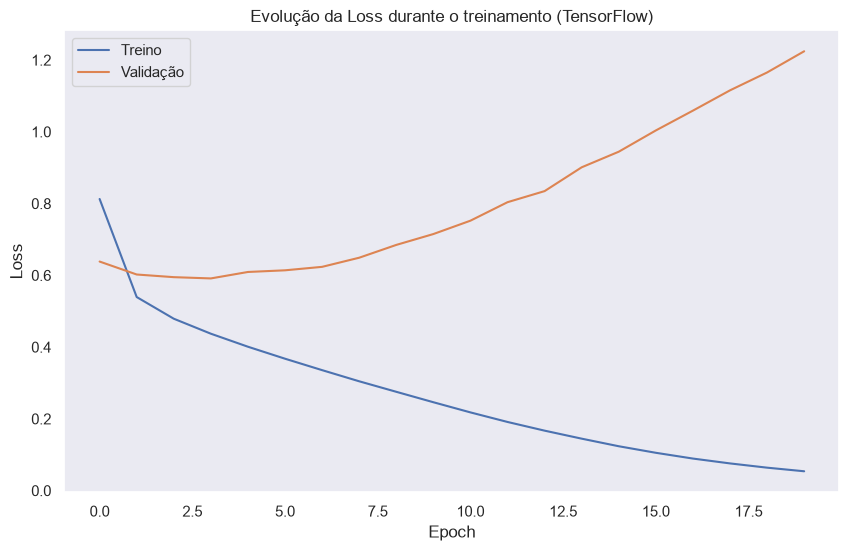

In [49]:
plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Evolução da Loss durante o treinamento (TensorFlow)')

plt.legend()
plt.grid()

plt.show()

# A rede começa a super-especializar (overfitting) a partir da epoch 5. A Val Loss atinge seu valor
# mínimo na epoch 4 (0.5913, correspondente ao maior val_accuracy = 0.8210) e volta a subir de forma
# constante a partir da epoch 5 (0.6093), chegando a 1.2244 na epoch 20, enquanto a Train Loss continua
# caindo monotonicamente até 0.0538. Esse comportamento é o mesmo observado na implementação em PyTorch
# (que também super-especializou a partir da epoch 5), e é o motivo de o ModelCheckpoint ter salvo os
# pesos da epoch 4 ('weights.h5') em vez dos da última epoch.

### Avaliando o modelo treinado

**Atividade (1 pt):** teste o modelo treinado utilizando o subconjunto de teste. Reporte a acurácia para cada classe e a matriz de confusão percentual (usando a função `evaluate` definida anteriormente).

1176/1176 [==============================] - 1s 847us/step
Accuracy: 0.832
Accuracy (balanced): 0.566


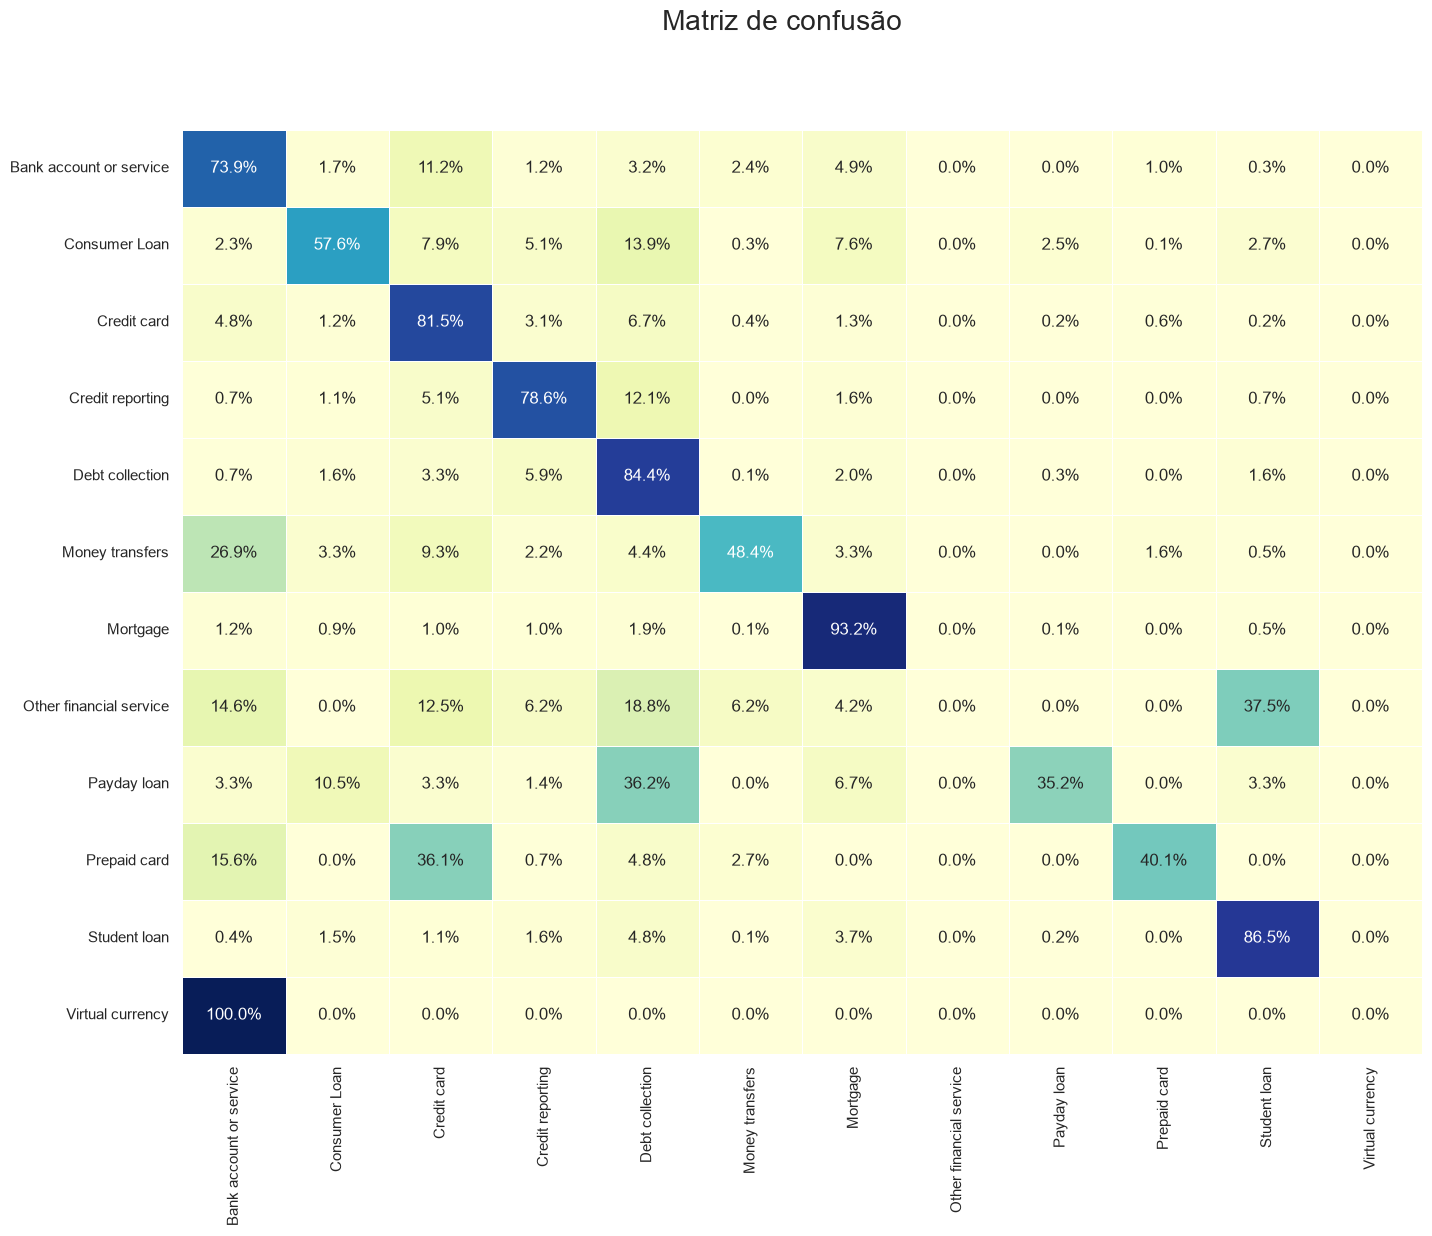

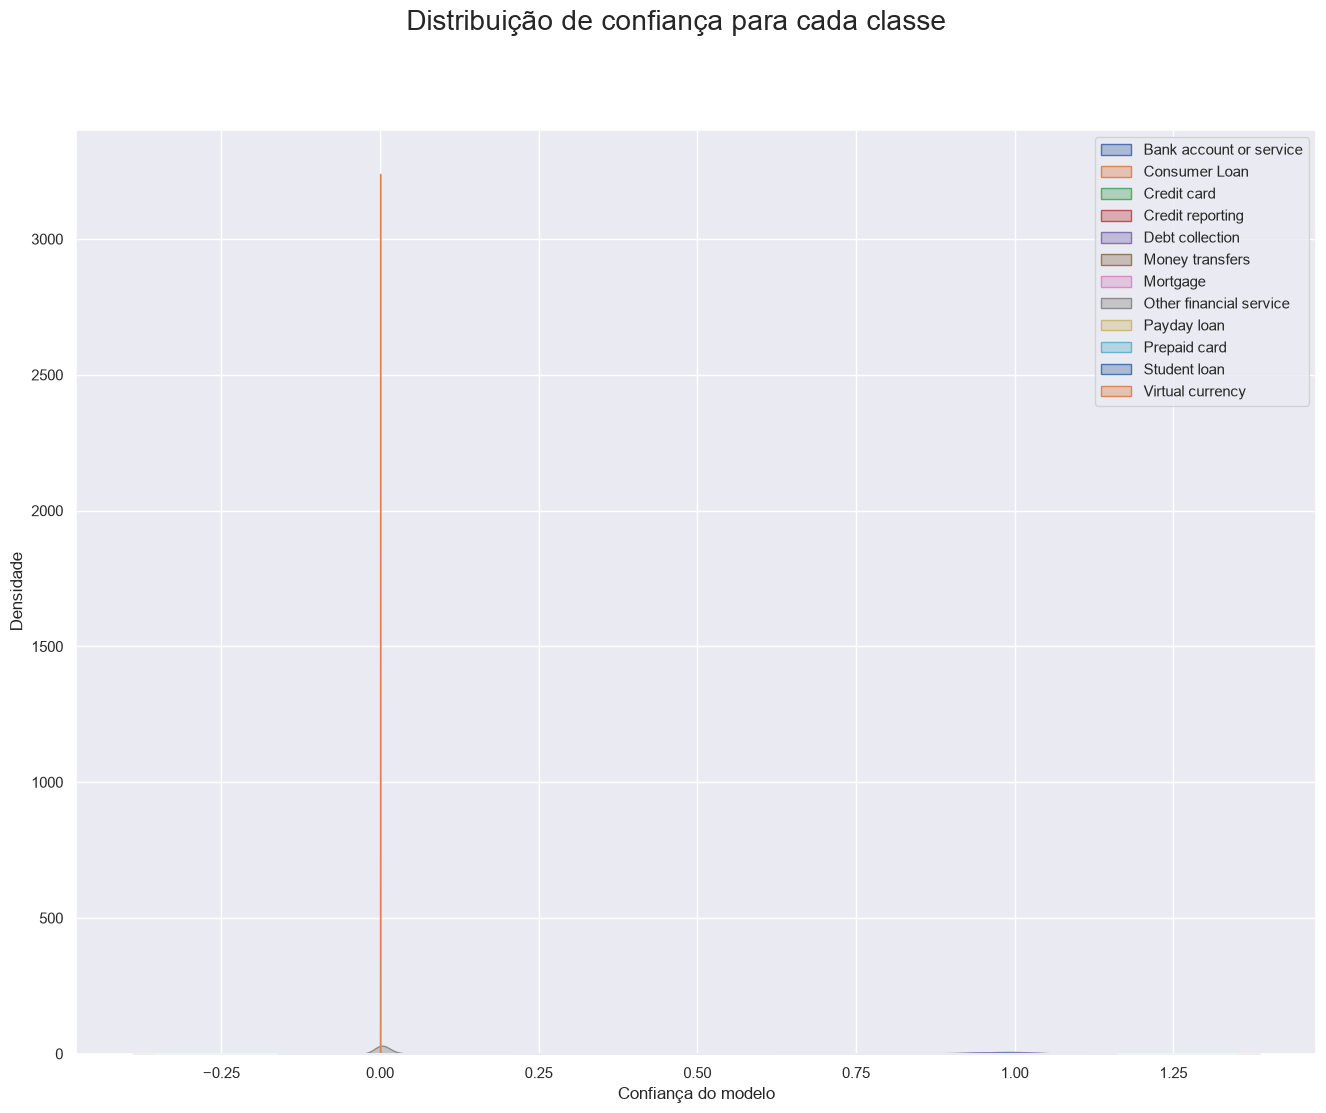

In [50]:
probabilities = model.predict(X_test_arr)
predictions = np.argmax(probabilities, axis=1)

evaluate(
    ye_test,
    predictions,
    probabilities,
    labels=label_enc.classes_
)

--------

Repita agora a definição, treinamento e avaliação de uma rede neural mais complexa, aumentando o número de camadas ou a quantidade de neurônios nas camadas da rede anterior:

**Atividade (1 pt):** defina uma rede neural mais complexa e a compile com as mesmas configurações da rede anterior.

In [51]:
def build_complex_model(input_size, num_classes):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_size,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=SGD(learning_rate=0.01),
        metrics=['accuracy']
    )

    return model

complex_model = build_complex_model(input_size=features, num_classes=num_classes)
complex_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 256)               262400    
                                                                 
 dense_4 (Dense)             (None, 128)               32896     
                                                                 
 dense_5 (Dense)             (None, 64)                8256      
                                                                 
 dense_6 (Dense)             (None, 12)                780       
                                                                 
Total params: 304332 (1.16 MB)
Trainable params: 304332 (1.16 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**Atividade (1 pt):** treine a nova rede.

In [52]:
checkpoint_complex = ModelCheckpoint(
    'weights_complex.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

history_complex = complex_model.fit(
    X_train_arr,
    y_ohe_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint_complex]
)

Epoch 1/20
3482/3500 [============================>.] - ETA: 0s - loss: 0.8153 - accuracy: 0.7468
Epoch 1: val_accuracy improved from -inf to 0.80701, saving model to weights_complex.h5
3500/3500 [==============================] - 8s 2ms/step - loss: 0.8141 - accuracy: 0.7471 - val_loss: 0.6288 - val_accuracy: 0.8070
Epoch 2/20
3494/3500 [============================>.] - ETA: 0s - loss: 0.5267 - accuracy: 0.8354
Epoch 2: val_accuracy improved from 0.80701 to 0.81083, saving model to weights_complex.h5
3500/3500 [==============================] - 8s 2ms/step - loss: 0.5265 - accuracy: 0.8354 - val_loss: 0.6115 - val_accuracy: 0.8108
Epoch 3/20
3492/3500 [============================>.] - ETA: 0s - loss: 0.4555 - accuracy: 0.8559
Epoch 3: val_accuracy improved from 0.81083 to 0.81897, saving model to weights_complex.h5
3500/3500 [==============================] - 9s 2ms/step - loss: 0.4555 - accuracy: 0.8559 - val_loss: 0.5860 - val_accuracy: 0.8190
Epoch 4/20
3485/3500 [===============

**Atividade (1 pt):** adicione dropout ou regularização L1/L2 e treine o novo modelo. Se for, preciso, faça uma busca pelos hipeparâmetros da regularização/dropout.

In [53]:
from tensorflow.keras.layers import Dropout

def build_dropout_model(input_size, num_classes, dropout=0.3):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_size,)),
        Dropout(dropout),
        Dense(128, activation='relu'),
        Dropout(dropout),
        Dense(64, activation='relu'),
        Dropout(dropout),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=SGD(learning_rate=0.01),
        metrics=['accuracy']
    )

    return model

dropout_values = [0.1, 0.3, 0.5]
results_dropout_tf = []

for dropout in dropout_values:
    print(f"\nTreinando com dropout = {dropout}")

    model_d = build_dropout_model(
        input_size=features,
        num_classes=num_classes,
        dropout=dropout
    )

    history_d = model_d.fit(
        X_train_arr,
        y_ohe_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=32,
        verbose=0
    )

    best_val_accuracy = max(history_d.history['val_accuracy'])

    results_dropout_tf.append({
        "dropout": dropout,
        "val_accuracy": best_val_accuracy
    })

    print(f"Melhor Val Accuracy: {best_val_accuracy:.4f}")

# RESULTADOS DA BUSCA
results_dropout_tf = pd.DataFrame(results_dropout_tf)
display(results_dropout_tf)

best_dropout_tf = results_dropout_tf.loc[
    results_dropout_tf["val_accuracy"].idxmax(),
    "dropout"
]

print(f"Melhor dropout: {best_dropout_tf}")

dropout_model = build_dropout_model(
    input_size=features,
    num_classes=num_classes,
    dropout=best_dropout_tf
)

checkpoint_dropout = ModelCheckpoint(
    'weights_dropout.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

history_dropout = dropout_model.fit(
    X_train_arr,
    y_ohe_train,
    validation_split=0.2,
    epochs=epochs,
    batch_size=32,
    callbacks=[checkpoint_dropout]
)


Treinando com dropout = 0.1
Melhor Val Accuracy: 0.8258

Treinando com dropout = 0.3
Melhor Val Accuracy: 0.8240

Treinando com dropout = 0.5
Melhor Val Accuracy: 0.8125


,dropout,val_accuracy
0,0.1,0.825832
1,0.3,0.824011
2,0.5,0.812545


Melhor dropout: 0.1
Epoch 1/5
3481/3500 [============================>.] - ETA: 0s - loss: 0.9512 - accuracy: 0.7039
Epoch 1: val_accuracy improved from -inf to 0.80447, saving model to weights_dropout.h5
3500/3500 [==============================] - 10s 3ms/step - loss: 0.9493 - accuracy: 0.7045 - val_loss: 0.6410 - val_accuracy: 0.8045
Epoch 2/5
3486/3500 [============================>.] - ETA: 0s - loss: 0.6222 - accuracy: 0.8088
Epoch 2: val_accuracy improved from 0.80447 to 0.81662, saving model to weights_dropout.h5
3500/3500 [==============================] - 9s 3ms/step - loss: 0.6218 - accuracy: 0.8088 - val_loss: 0.5947 - val_accuracy: 0.8166
Epoch 3/5
3478/3500 [============================>.] - ETA: 0s - loss: 0.5498 - accuracy: 0.8292
Epoch 3: val_accuracy improved from 0.81662 to 0.82412, saving model to weights_dropout.h5
3500/3500 [==============================] - 9s 3ms/step - loss: 0.5494 - accuracy: 0.8294 - val_loss: 0.5679 - val_accuracy: 0.8241
Epoch 4/5
3495/3500

**Atividade (1 pt):** avalie os modelos treinados e compare com os resultados anteriores.

1176/1176 [==============================] - 1s 1ms/step
Accuracy: 0.832
Accuracy (balanced): 0.565
1176/1176 [==============================] - 1s 1ms/step
Accuracy: 0.837
Accuracy (balanced): 0.571


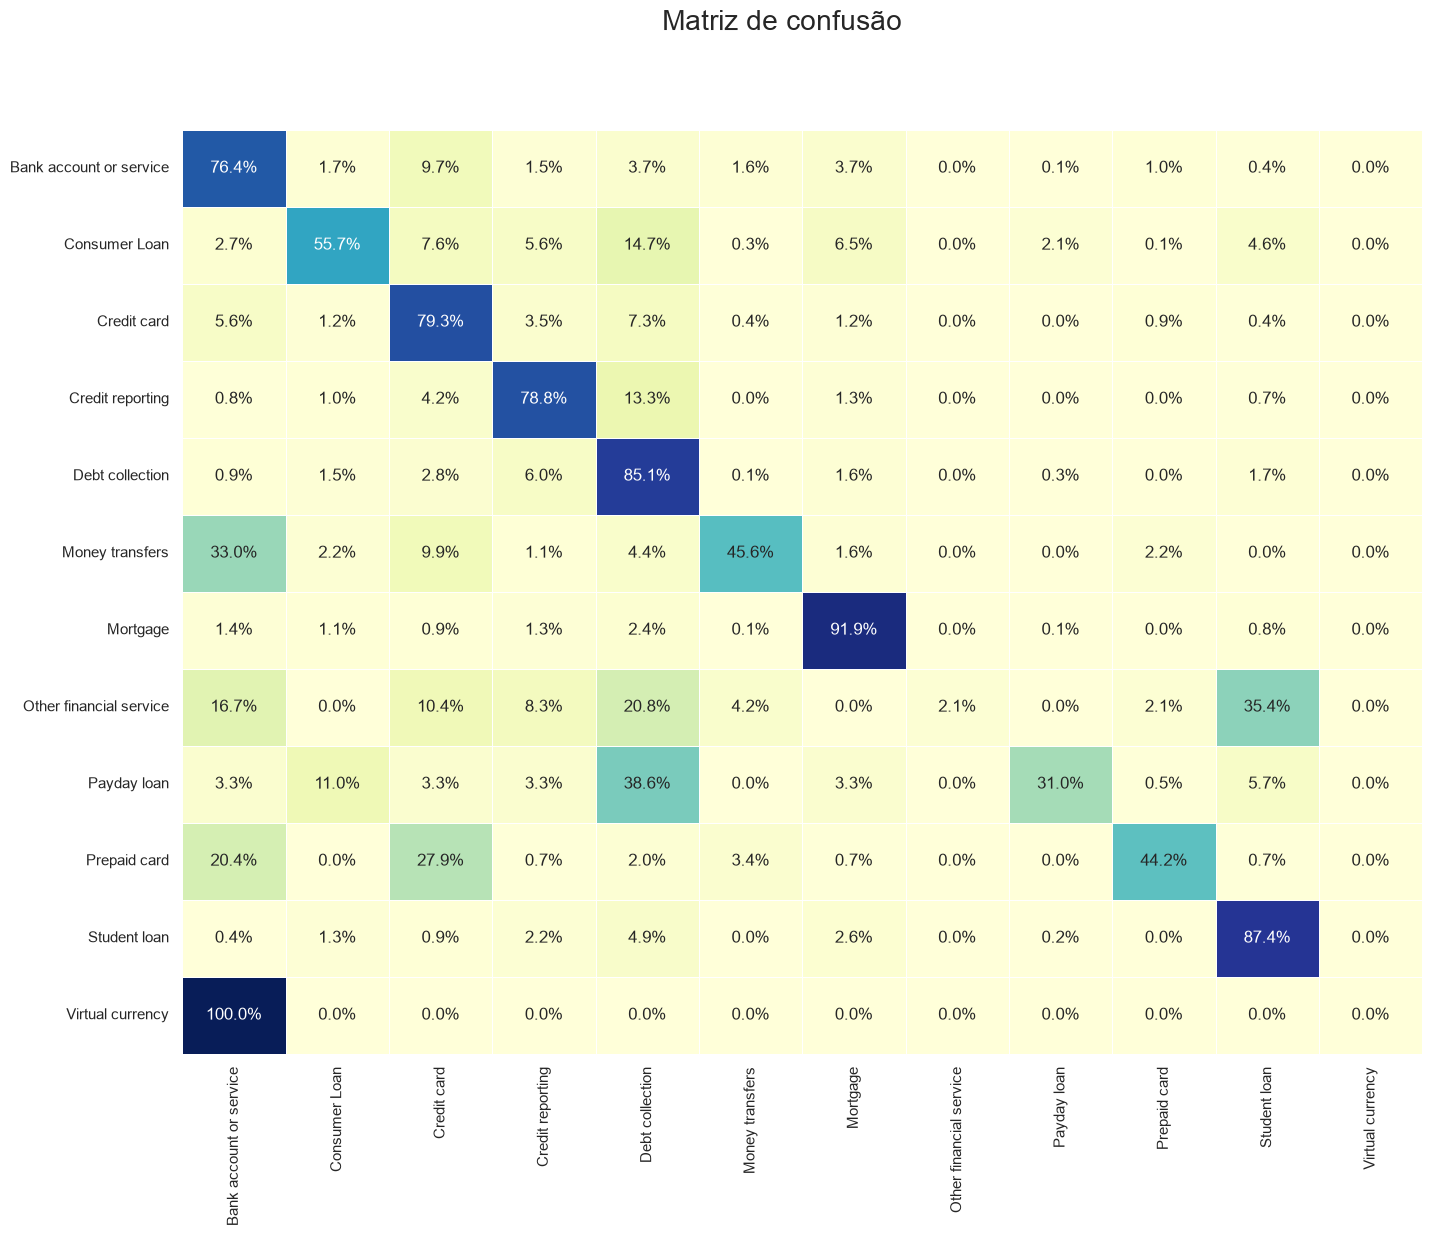

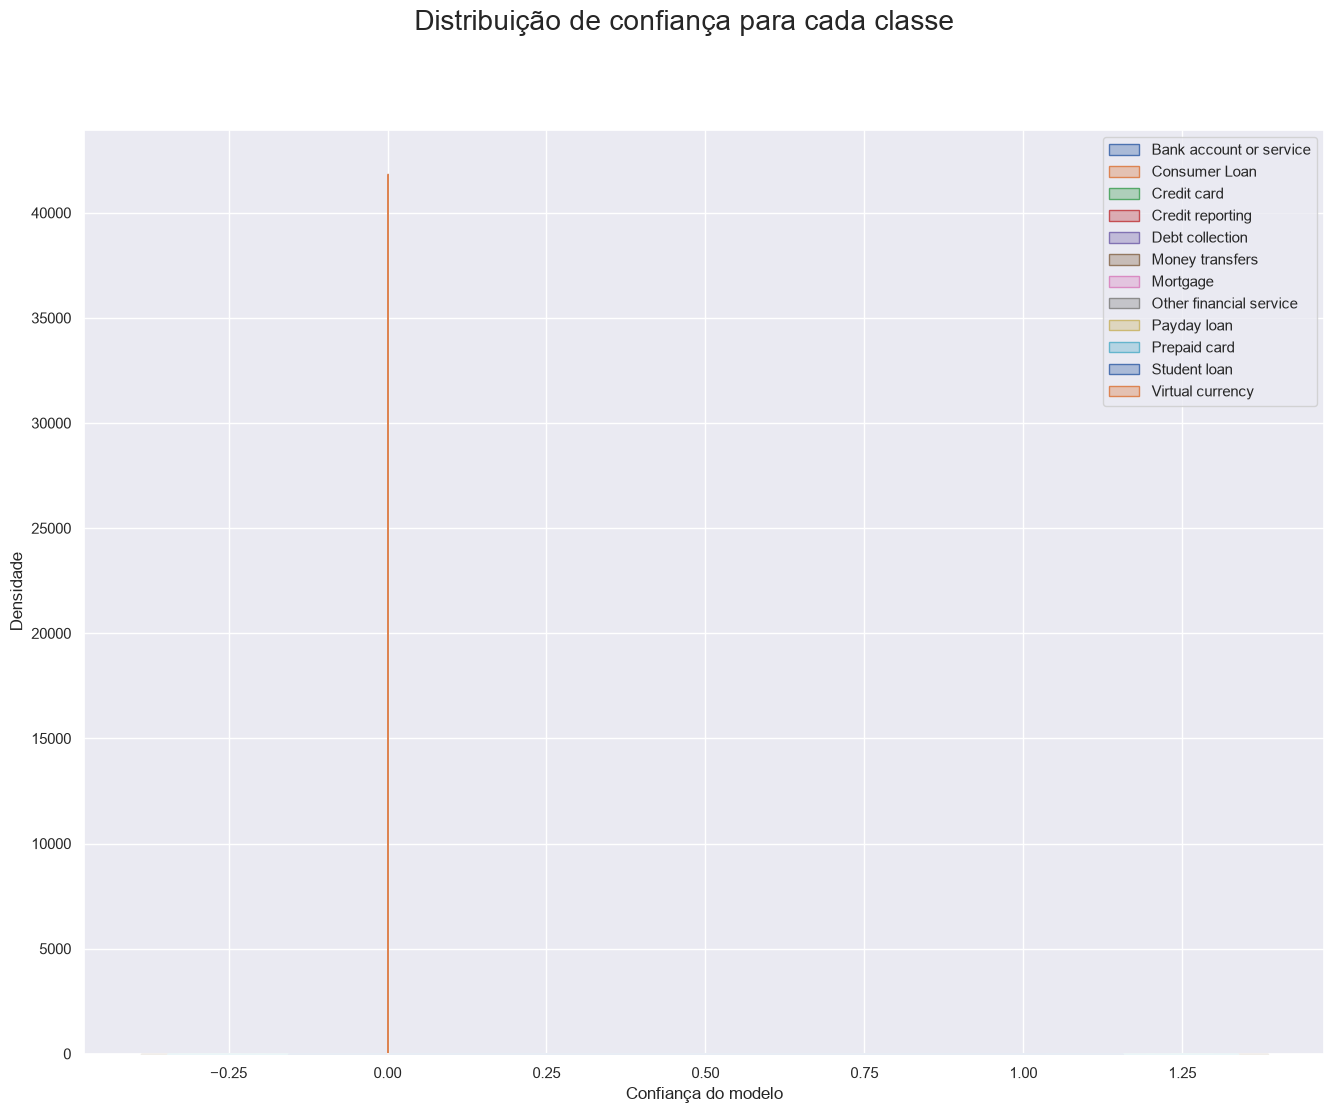

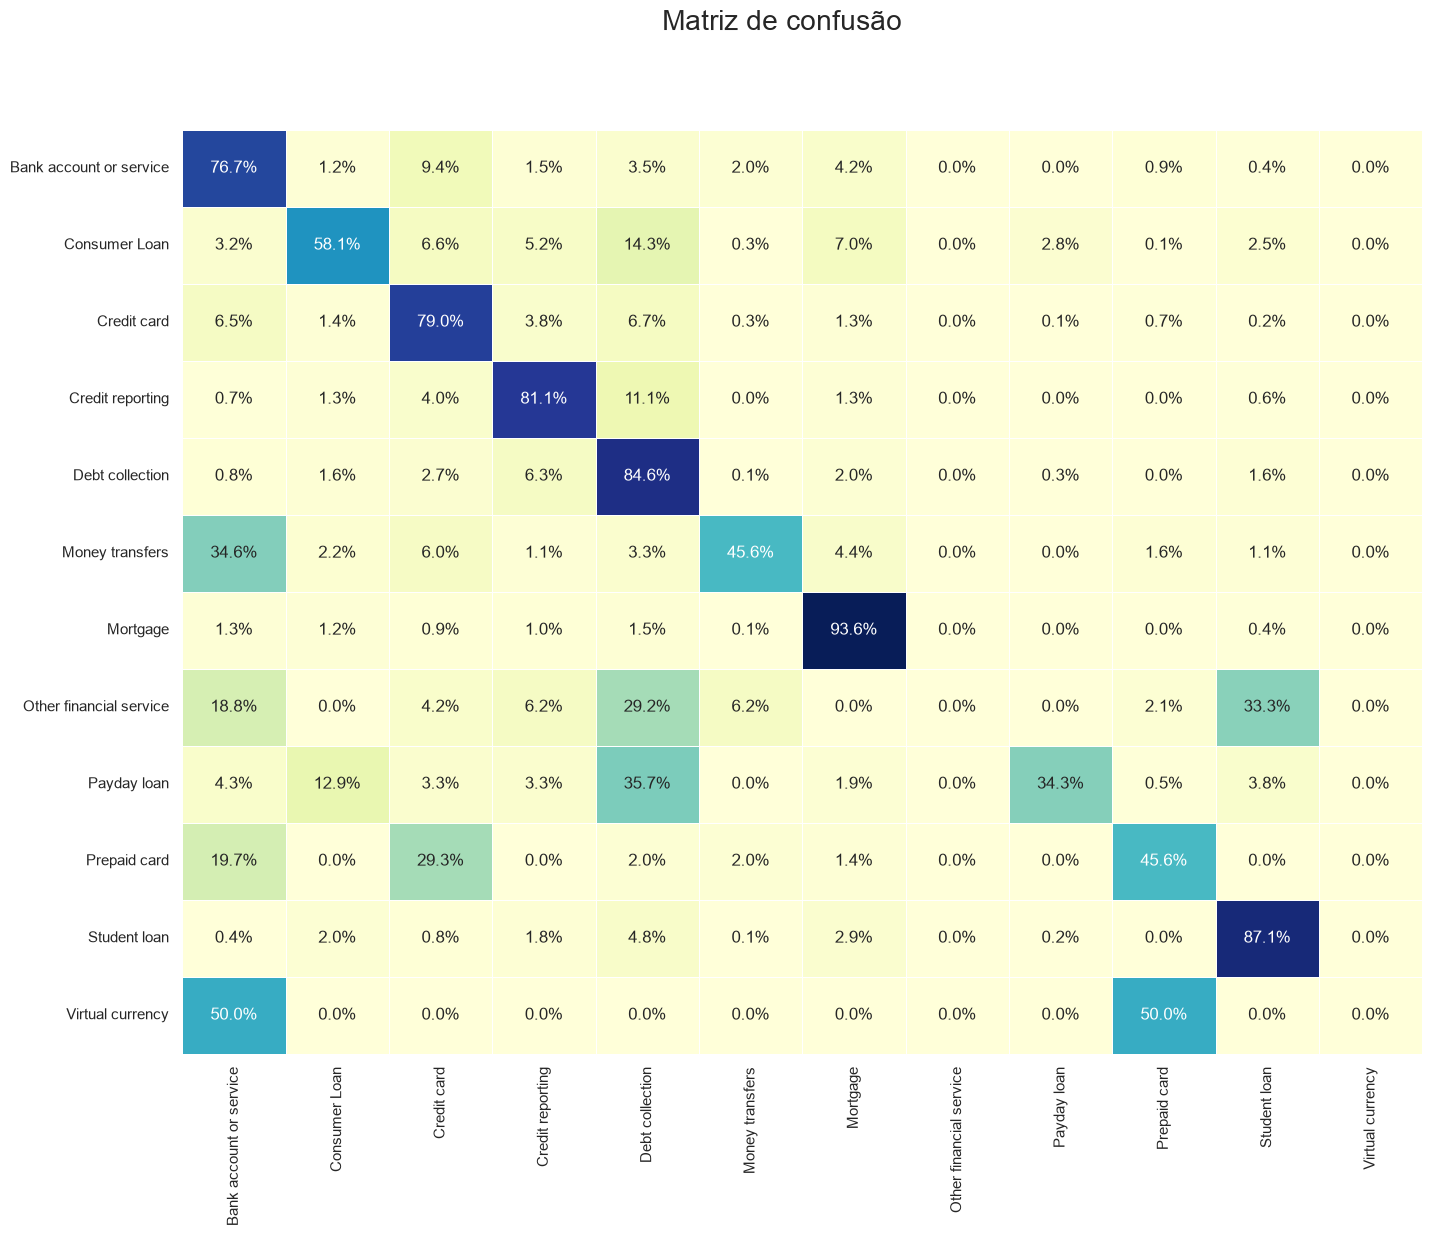

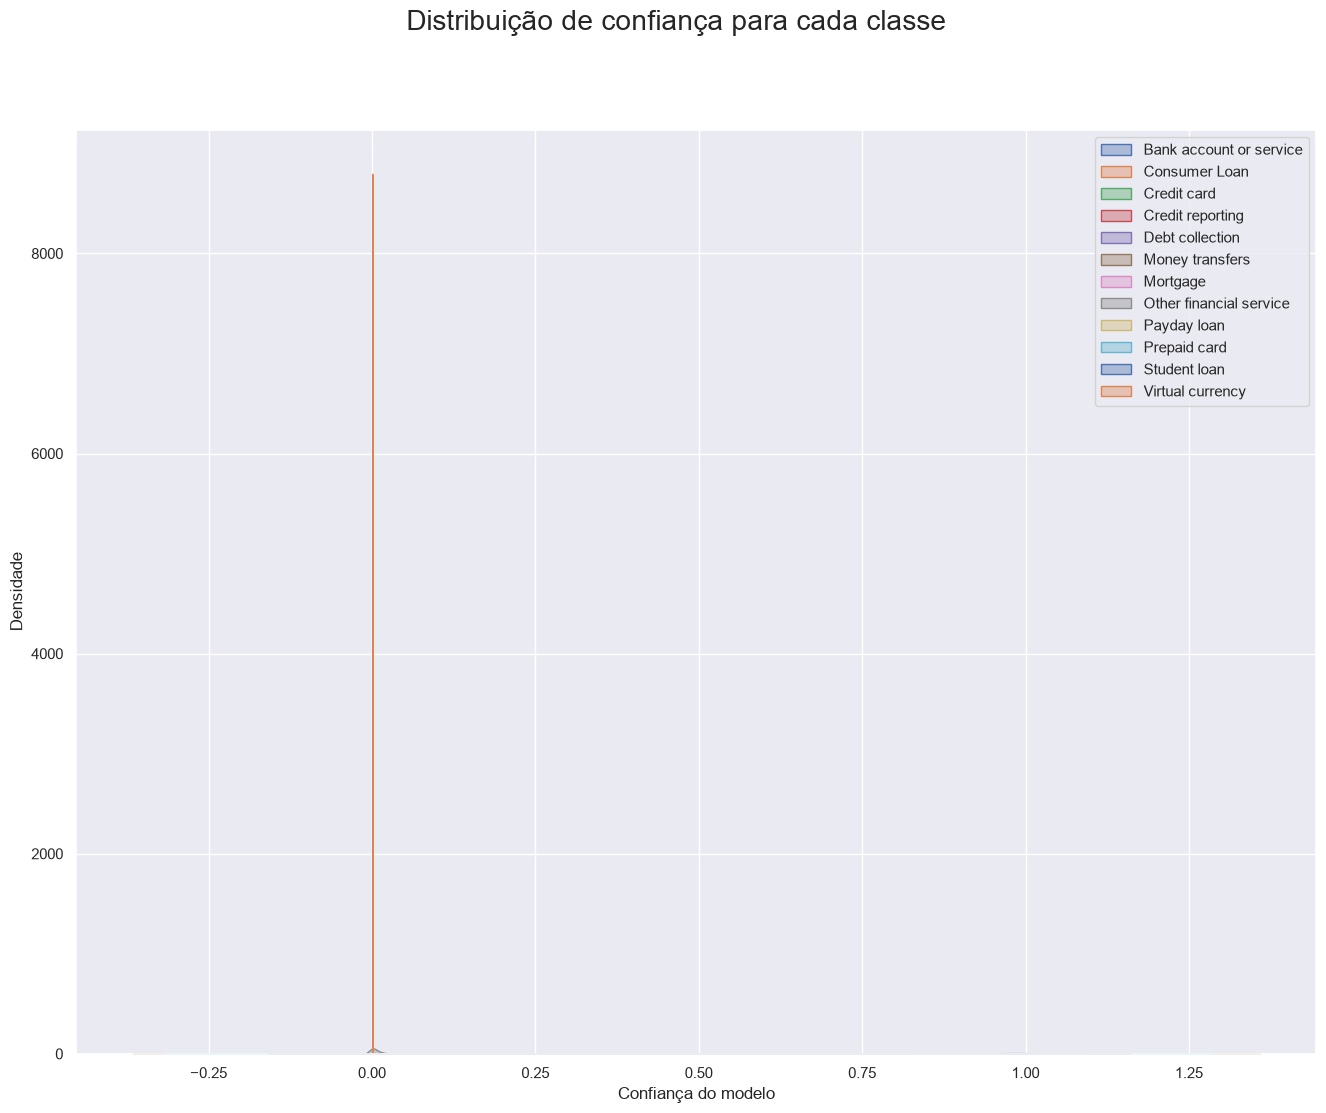

In [ ]:
complex_model.load_weights('weights_complex.h5')

probabilities_complex = complex_model.predict(X_test_arr)
predictions_complex = np.argmax(probabilities_complex, axis=1)

evaluate(
    ye_test,
    predictions_complex,
    probabilities_complex,
    labels=label_enc.classes_
)

dropout_model.load_weights('weights_dropout.h5')

probabilities_dropout = dropout_model.predict(X_test_arr)
predictions_dropout = np.argmax(probabilities_dropout, axis=1)

evaluate(
    ye_test,
    predictions_dropout,
    probabilities_dropout,
    labels=label_enc.classes_
)


# Comparando os três modelos treinados em TensorFlow (resultados reais desta execução):
#
#  Modelo                               Accuracy  Balanced Accuracy 
# ------------------------------------------------------------------
#  Rede simples (2 camadas ocultas)     0.832     0.566              
#  Rede complexa (3 camadas, sem reg.)  0.832     0.565              
#  Rede complexa + dropout (0.1)        0.837     0.571              
#
# Diferente do que se observou na implementação em PyTorch (onde a rede complexa piorou claramente
# em relação à simples), aqui a rede complexa sem regularização praticamente empatou com a rede simples
# (0.565 vs 0.566 de balanced accuracy) -- apesar do forte overfitting visível no treino (train accuracy
# de 99.7% contra val_accuracy estagnada em ~82%, com val_loss subindo de 0.63 para 1.46 ao longo de 20
# epochs). O ModelCheckpoint evita que esse overfitting prejudique o resultado final, pois os pesos
# salvos são sempre os da epoch com melhor val_accuracy (epoch 5, 0.8197), não os da última epoch --
# por isso o desempenho no teste não caiu tanto quanto a curva de treino sugeriria.
#
# A adição de dropout (0.1) foi o único ajuste que trouxe uma melhora real, tanto em accuracy (0.837,
# a maior entre os três) quanto em balanced accuracy (0.571, também a maior). Isso é coerente com o papel
# do dropout como regularizador: mesmo com poucas epochs (5, contra 20 das redes anteriores), ele já reduz
# a dependência de neurônios específicos e melhora a generalização. Em resumo, para este problema a maior
# capacidade da rede complexa por si só não trouxe ganho sobre a rede simples, mas combinada com dropout
# produziu o melhor resultado entre os modelos TensorFlow testados.